# 07: Multi-Class Attack Classification

This notebook trains and evaluates multiple classifiers on the multi-class attack classification task — predicting the specific attack category for each traffic record. The same four models from notebook 06 are used: Logistic Regression (baseline), Random Forest, XGBoost, and Multi-Layer Perceptron. Macro F1 is used as the primary ranking metric so that rare attack categories are weighted equally alongside common ones.

The notebook covers Cross-Validation evaluation, feature importance, test-set evaluation, Precision-Recall analysis, hyperparameter tuning, stacking ensemble construction, SHAP and LIME explainability, misclassification analysis, calibration, learning curves, Partial Dependence Plots, inference speed benchmarking, and live detection simulation. The final stacking ensemble is saved to `models/stacking_classifier.joblib`.

## 7.1: Import Libraries

This section loads all Python libraries used throughout the notebook. Having all imports in one place makes it easy to identify dependencies and ensures the notebook fails early with a clear message if a required package is missing. The imports cover data manipulation (pandas, numpy), visualisation (matplotlib, seaborn), machine learning (scikit-learn, xgboost), explainability (shap, lime), and utility modules (joblib, timeit, warnings).

In [1]:
import warnings
# Suppress tqdm's IProgress warning when ipywidgets is not installed in the Jupyter environment.
warnings.filterwarnings('ignore', message='IProgress not found')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xgboost as xgb
from sklearn.calibration import calibration_curve
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    f1_score,
    accuracy_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_predict,
    cross_validate,
    RandomizedSearchCV,
    learning_curve,
    train_test_split,
)
from sklearn.neural_network import MLPClassifier
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.isotonic import IsotonicRegression
from sklearn.preprocessing import label_binarize
import shap
import lime
import lime.lime_tabular as lime_tabular
import timeit
import joblib
import os

# Prevent truncation of long column values in displayed DataFrames.
pd.set_option('display.max_colwidth', None)

# Set a white grid background for all plots.
sns.set_style('whitegrid')

## 7.2: Load Data

This section loads the engineered training and test splits produced by `05_feature_engineering.ipynb`. Both files contain the same set of features plus the two target columns (`Label` and `attack_cat`). Loading both splits here confirms that the feature engineering pipeline ran successfully and that the expected number of rows and columns are present before any modelling begins.

In [2]:
# Load the engineered train and test splits produced by 05_feature_engineering.ipynb.
# Both files contain the same feature columns plus the two target columns (Label, attack_cat).
train = pd.read_csv('../data/engineered/train.csv', low_memory=False)
test = pd.read_csv('../data/engineered/test.csv', low_memory=False)

print(f'Train shape: {train.shape}')
print(f'Test shape:  {test.shape}')

Train shape: (272268, 49)
Test shape:  (404894, 49)


## 7.3: Prepare Features and Target

This section separates the feature matrix from the target column and restricts both the training and test sets to attack traffic only. The multi-class classifier predicts the specific attack category for a given record — it is not responsible for distinguishing normal from malicious traffic, which is the role of the binary classifier in notebook 06. Including Normal records would inflate accuracy metrics without improving the model's ability to discriminate between attack types, and would bias macro F1 scores away from the rare attack categories of greatest interest.

The integer-encoded `attack_cat` labels produced by `05_feature_engineering.ipynb` originally span 0–9 (alphabetical order, including Normal=6). After filtering out Normal records, the remaining integers are non-contiguous (0–5, 7–9). They are re-encoded to contiguous 0–8 to satisfy XGBoost's class label requirement. Class distributions are printed for both splits to confirm the filtering and re-encoding applied correctly.

In [3]:
# Both target columns are dropped to form the feature matrix.
# Label is excluded here because this notebook only trains the multi-class classifier;
# it was the target in 06_modelling_binary.ipynb instead.
DROP_COLUMNS = ['Label', 'attack_cat']

# The original attack_cat encoding from 05_feature_engineering.ipynb:
# 0=Analysis, 1=Backdoor, 2=DoS, 3=Exploits, 4=Fuzzers, 5=Generic,
# 6=Normal, 7=Reconnaissance, 8=Shellcode, 9=Worms.

# Filter to attack traffic only — Normal (6) is excluded because this classifier
# predicts the attack type, not whether traffic is normal or malicious.
NORMAL_ORIGINAL_INT = 6
train_attack = train[train['attack_cat'] != NORMAL_ORIGINAL_INT].copy()
test_attack = test[test['attack_cat'] != NORMAL_ORIGINAL_INT].copy()

features_train = train_attack.drop(columns=DROP_COLUMNS)
features_test = test_attack.drop(columns=DROP_COLUMNS)

# Re-encode labels to contiguous integers 0–8.
# Removing Normal (6) leaves a gap: 0,1,2,3,4,5,7,8,9.
# XGBoost requires contiguous class labels starting at 0.
RECODE = {0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 7: 6, 8: 7, 9: 8}

labels_train = train_attack['attack_cat'].map(RECODE)
labels_test = test_attack['attack_cat'].map(RECODE)

# ATTACK_CAT_MAPPING maps the new contiguous integer codes to category names.
# Used for display in classification reports, confusion matrices, and plots.
ATTACK_CAT_MAPPING = {
    0: 'Analysis',
    1: 'Backdoor',
    2: 'DoS',
    3: 'Exploits',
    4: 'Fuzzers',
    5: 'Generic',
    6: 'Reconnaissance',
    7: 'Shellcode',
    8: 'Worms',
}

# CLASS_NAMES maps integer codes to category names, ordered by code (alphabetical).
# Used as target_names in classification reports and display labels in plots.
CLASS_NAMES = [ATTACK_CAT_MAPPING[i] for i in sorted(ATTACK_CAT_MAPPING.keys())]

# Print class distributions to confirm filtering and resampling (train) and natural split (test).
print('Attack categories in training set:')
print(labels_train.value_counts().sort_index().to_frame('count'))
print('\nAttack categories in test set:')
print(labels_test.value_counts().sort_index().to_frame('count'))

Attack categories in training set:
            count
attack_cat       
0            4000
1            2000
2            5000
3           15000
4           15000
5           15000
6            8067
7            3000
8            1000

Attack categories in test set:
            count
attack_cat       
0             430
1             377
2            1116
3            5494
4            4153
5            3735
6            2047
7             294
8              32


## 7.4: Cross-Validation Setup

This section configures the cross-validation strategy used to evaluate all four models consistently before any test data is seen. Stratified 5-fold cross-validation is applied to the training set, where each fold preserves the per-category class proportions — this is essential for a resampled multi-class dataset where fold composition directly affects scores on rare attack categories. Using cross-validation rather than a single train–validation split reduces the variance of the score estimate and ensures the reported metrics are not an artefact of a particularly easy or difficult validation partition. Three metrics are collected per fold: accuracy (overall correctness), macro F1 (primary ranking metric — treats every category equally regardless of sample count), and weighted F1 (accounts for category frequency).

In [4]:
# StratifiedKFold preserves the class ratio in every fold, which matters here because
# the resampled training set has varying counts per attack category.
# shuffle=True randomises the fold assignment before splitting.
STRATIFIED_KFOLD = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Metrics collected per fold:
# accuracy    — overall correct predictions across all classes
# f1_macro    — unweighted average F1 across all classes; treats every category equally (primary metric)
# f1_weighted — F1 weighted by class support; gives more weight to common categories
SCORING = ['accuracy', 'f1_macro', 'f1_weighted']

# Dictionary to accumulate CV results for each model so they can be compared in section 7.9.
cross_validation_results = {}

## 7.5: Logistic Regression

Logistic Regression serves as the baseline model. A strong baseline is important because it sets the minimum performance bar that more complex models must exceed to justify their additional training cost and inference latency. Without a baseline, it is impossible to know whether a more sophisticated model is genuinely learning useful patterns or simply exploiting dataset properties that any classifier could exploit. For multi-class problems, scikit-learn applies a one-vs-rest strategy by default, training one binary classifier per category and assigning the class with the highest predicted probability. The reader should expect this model to achieve the lowest Cross-Validation macro F1 among the four models, as it cannot capture the non-linear relationships present in network traffic features.

In [5]:
# max_iter=1000 — default 100 is often too low for standardised data with many features;
# increasing it ensures the solver converges rather than stopping early.
logistic_regression = LogisticRegression(max_iter=1000, random_state=42)

# cross_validate runs the full fit-predict cycle for each CV fold and returns per-fold scores.
cross_validation_results['Logistic Regression'] = cross_validate(logistic_regression, features_train, labels_train, cv=STRATIFIED_KFOLD, scoring=SCORING, n_jobs=-1)

print('=== Logistic Regression — Cross-Validation Scores ===')
for metric in SCORING:
    scores = cross_validation_results['Logistic Regression'][f'test_{metric}']

    # Report mean ± std across folds — std indicates how stable the score is across folds.
    print(f'{metric:12s}: {scores.mean():.4f} ± {scores.std():.4f}')

# cross_val_predict returns one prediction per training sample, each made by a fold
# that did not include that sample during training (out-of-fold / OOF predictions).
# This gives a fair per-class breakdown without touching the held-out test set.
logistic_regression_out_of_fold = cross_val_predict(logistic_regression, features_train, labels_train, cv=STRATIFIED_KFOLD, n_jobs=-1)
print('\n=== Logistic Regression — Classification Report (Cross-Validation Out-of-Fold) ===')
print(classification_report(labels_train, logistic_regression_out_of_fold, target_names=CLASS_NAMES, digits=4))

=== Logistic Regression — Cross-Validation Scores ===
accuracy    : 0.6523 ± 0.0025
f1_macro    : 0.4650 ± 0.0025
f1_weighted : 0.6364 ± 0.0014

=== Logistic Regression — Classification Report (Cross-Validation Out-of-Fold) ===
                precision    recall  f1-score   support

      Analysis     0.3277    0.7700    0.4597      4000
      Backdoor     0.2651    0.0220    0.0406      2000
           DoS     0.2430    0.0540    0.0884      5000
      Exploits     0.6268    0.7534    0.6843     15000
       Fuzzers     0.7727    0.8049    0.7885     15000
       Generic     0.9495    0.7349    0.8285     15000
Reconnaissance     0.5666    0.5681    0.5674      8067
     Shellcode     0.5082    0.6413    0.5670      3000
         Worms     0.4008    0.1010    0.1613      1000

      accuracy                         0.6523     68067
     macro avg     0.5178    0.4944    0.4651     68067
  weighted avg     0.6580    0.6523    0.6364     68067



## 7.6: Random Forest

Random Forest is an ensemble of decision trees, each trained on a bootstrap sample of rows and a randomly selected subset of features. This double randomisation decorrelates the individual trees and reduces overfitting compared to a single deep decision tree. Random Forest handles non-linear relationships and feature interactions natively, requires minimal preprocessing, and produces native feature importances (used in section 7.10) as a by-product of training. It is a strong candidate for the best performer on this dataset and will be evaluated head-to-head against XGBoost in the model comparison. The reader should expect mean Cross-Validation macro F1 and accuracy scores for each fold.

In [6]:
# n_estimators=100 — number of trees in the forest; more trees reduce variance but increase
# training time. 100 is a reasonable starting point for this dataset size.
# Each tree is trained on a bootstrap sample of rows and a random subset of features,
# which decorrelates the trees and reduces overfitting compared to a single decision tree.
random_forest = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

cross_validation_results['Random Forest'] = cross_validate(random_forest, features_train, labels_train, cv=STRATIFIED_KFOLD, scoring=SCORING, n_jobs=-1)

print('=== Random Forest — Cross-Validation Scores ===')
for metric in SCORING:
    scores = cross_validation_results['Random Forest'][f'test_{metric}']
    print(f'{metric:12s}: {scores.mean():.4f} ± {scores.std():.4f}')

# OOF predictions — each sample is predicted by trees trained without it.
random_forest_out_of_fold = cross_val_predict(random_forest, features_train, labels_train, cv=STRATIFIED_KFOLD, n_jobs=-1)
print('\n=== Random Forest — Classification Report (Cross-Validation Out-of-Fold) ===')
print(classification_report(labels_train, random_forest_out_of_fold, target_names=CLASS_NAMES, digits=4))

=== Random Forest — Cross-Validation Scores ===
accuracy    : 0.8102 ± 0.0033
f1_macro    : 0.7547 ± 0.0048
f1_weighted : 0.8159 ± 0.0030

=== Random Forest — Classification Report (Cross-Validation Out-of-Fold) ===
                precision    recall  f1-score   support

      Analysis     0.4346    0.6955    0.5349      4000
      Backdoor     0.3155    0.3505    0.3321      2000
           DoS     0.6209    0.5644    0.5913      5000
      Exploits     0.8396    0.8231    0.8313     15000
       Fuzzers     0.9149    0.8907    0.9026     15000
       Generic     0.9384    0.8693    0.9025     15000
Reconnaissance     0.8411    0.7705    0.8043      8067
     Shellcode     0.8873    0.9633    0.9238      3000
         Worms     0.9467    0.9940    0.9698      1000

      accuracy                         0.8102     68067
     macro avg     0.7488    0.7690    0.7547     68067
  weighted avg     0.8266    0.8102    0.8159     68067



## 7.7: XGBoost

XGBoost is a gradient-boosted tree ensemble that builds trees sequentially, where each new tree is trained to correct the residual errors of the current ensemble. It applies regularisation terms (L1 and L2) to the tree weights, which prevents overfitting and makes it more robust than unregularised gradient boosting. XGBoost consistently performs well on structured and tabular data and is often the top performer in benchmark comparisons for this data type. It will be directly compared to Random Forest in the model comparison section, and the better-performing configuration will later be tuned via hyperparameter search in section 7.13. The reader should expect Cross-Validation macro F1 scores comparable to or exceeding those of Random Forest.

In [7]:
# XGBoost builds trees sequentially; each new tree corrects the residual errors of the
# ensemble so far.
# Key parameters:
# learning_rate=0.1      — shrinks each tree's contribution; lower values require more trees
#                          but generalise better. Paired with n_estimators=100 as a starting point.
# max_depth=6            — maximum depth per tree; deeper trees capture more complex patterns
#                          but are more prone to overfitting.
# eval_metric='mlogloss' — multiclass log loss; the multi-class equivalent of binary cross-entropy.
# verbosity=0            — suppress training output to keep the notebook output clean.
xgboost_classifier = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss',
    verbosity=0,
)

cross_validation_results['XGBoost'] = cross_validate(xgboost_classifier, features_train, labels_train, cv=STRATIFIED_KFOLD, scoring=SCORING, n_jobs=-1)

print('=== XGBoost — Cross-Validation Scores ===')
for metric in SCORING:
    scores = cross_validation_results['XGBoost'][f'test_{metric}']
    print(f'{metric:12s}: {scores.mean():.4f} ± {scores.std():.4f}')

# OOF predictions for classification report
xgboost_out_of_fold = cross_val_predict(xgboost_classifier, features_train, labels_train, cv=STRATIFIED_KFOLD, n_jobs=-1)
print('\n=== XGBoost — Classification Report (Cross-Validation Out-of-Fold) ===')
print(classification_report(labels_train, xgboost_out_of_fold, target_names=CLASS_NAMES, digits=4))

=== XGBoost — Cross-Validation Scores ===
accuracy    : 0.7809 ± 0.0025
f1_macro    : 0.6965 ± 0.0037
f1_weighted : 0.7797 ± 0.0026

=== XGBoost — Classification Report (Cross-Validation Out-of-Fold) ===
                precision    recall  f1-score   support

      Analysis     0.3567    0.9617    0.5204      4000
      Backdoor     0.4282    0.1820    0.2554      2000
           DoS     0.6664    0.2038    0.3121      5000
      Exploits     0.7734    0.8107    0.7916     15000
       Fuzzers     0.9148    0.8859    0.9001     15000
       Generic     0.9654    0.8410    0.8989     15000
Reconnaissance     0.8842    0.7774    0.8274      8067
     Shellcode     0.7621    0.8660    0.8107      3000
         Worms     0.9152    0.9930    0.9525      1000

      accuracy                         0.7809     68067
     macro avg     0.7407    0.7246    0.6966     68067
  weighted avg     0.8191    0.7809    0.7797     68067



## 7.8: Multi-Layer Perceptron

A Multi-Layer Perceptron (MLP) is a feedforward neural network that learns representations through successive layers of non-linear transformations. With the volume of training data available in this dataset, the MLP has sufficient signal to learn complex non-linear decision boundaries across all attack categories. Unlike tree-based models, the MLP is sensitive to feature scale and requires standardised inputs — the standardisation applied in notebook 05 satisfies this requirement. The architecture used here consists of two hidden layers. The reader should expect Cross-Validation macro F1 scores competitive with the tree-based models, although training will be slower due to the iterative weight optimisation process.

In [8]:
# An MLP learns by passing inputs forward through layers of neurons (forward pass),
# computing a loss, then adjusting weights via backpropagation.
# Key parameters:
# hidden_layer_sizes=(128, 64) — two hidden layers with 128 and 64 neurons respectively;
#                                the network narrows as it abstracts features.
# activation='relu'            — Rectified Linear Unit; avoids the vanishing gradient
#                                problem common with sigmoid/tanh in deep networks.
# max_iter=200                 — maximum number of training epochs.
# early_stopping=True          — halts training when validation loss stops improving,
#                                preventing overfitting without manual epoch tuning.
# validation_fraction=0.1      — 10% of training data held back internally to monitor
#                                the early stopping criterion.
multilayer_perceptron = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    max_iter=200,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
)

cross_validation_results['MLP'] = cross_validate(multilayer_perceptron, features_train, labels_train, cv=STRATIFIED_KFOLD, scoring=SCORING, n_jobs=-1)

print('=== MLP — Cross-Validation Scores ===')
for metric in SCORING:
    scores = cross_validation_results['MLP'][f'test_{metric}']
    print(f'{metric:12s}: {scores.mean():.4f} ± {scores.std():.4f}')

# OOF predictions for classification report
multilayer_perceptron_out_of_fold = cross_val_predict(multilayer_perceptron, features_train, labels_train, cv=STRATIFIED_KFOLD, n_jobs=-1)
print('\n=== MLP — Classification Report (Cross-Validation Out-of-Fold) ===')
print(classification_report(labels_train, multilayer_perceptron_out_of_fold, target_names=CLASS_NAMES, digits=4))

=== MLP — Cross-Validation Scores ===
accuracy    : 0.7488 ± 0.0030
f1_macro    : 0.6391 ± 0.0119
f1_weighted : 0.7455 ± 0.0050

=== MLP — Classification Report (Cross-Validation Out-of-Fold) ===
                precision    recall  f1-score   support

      Analysis     0.3466    0.9360    0.5059      4000
      Backdoor     0.4192    0.1285    0.1967      2000
           DoS     0.4970    0.1638    0.2464      5000
      Exploits     0.7375    0.7699    0.7533     15000
       Fuzzers     0.8876    0.8615    0.8743     15000
       Generic     0.9488    0.8207    0.8801     15000
Reconnaissance     0.8363    0.7750    0.8045      8067
     Shellcode     0.7126    0.7883    0.7485      3000
         Worms     0.7384    0.7510    0.7447      1000

      accuracy                         0.7488     68067
     macro avg     0.6804    0.6661    0.6394     68067
  weighted avg     0.7778    0.7488    0.7455     68067



## 7.9: Model Comparison

This section summarises and ranks all four models by their mean Cross-Validation macro F1 score. Macro F1 is the primary ranking metric because it treats every attack category equally — a model that performs well on common categories like Generic but poorly on rare ones like Worms or Analysis would achieve a misleadingly high weighted F1, but its macro F1 would expose the poor performance on underrepresented classes. The model with the highest mean macro F1 is selected as the best model and will be evaluated on the held-out test set in section 7.11. A bar chart provides a visual comparison across all three collected metrics simultaneously.

In [9]:
# Build a summary DataFrame of mean CV scores for each model.
# Sorting by F1 macro treats every attack category equally — a model that performs
# well on common categories but poorly on rare ones will rank lower than one that
# handles all categories consistently.
rows = []
for name, results in cross_validation_results.items():
    rows.append({
        'Model': name,
        'Accuracy': results['test_accuracy'].mean(),
        'F1 (macro)': results['test_f1_macro'].mean(),
        'F1 (weighted)': results['test_f1_weighted'].mean(),
    })

comparison = pd.DataFrame(rows).set_index('Model').round(4)
comparison = comparison.sort_values('F1 (macro)', ascending=False)
print(comparison)

                     Accuracy  F1 (macro)  F1 (weighted)
Model                                                   
Random Forest          0.8102      0.7547         0.8159
XGBoost                0.7809      0.6965         0.7797
MLP                    0.7488      0.6391         0.7455
Logistic Regression    0.6523      0.4650         0.6364


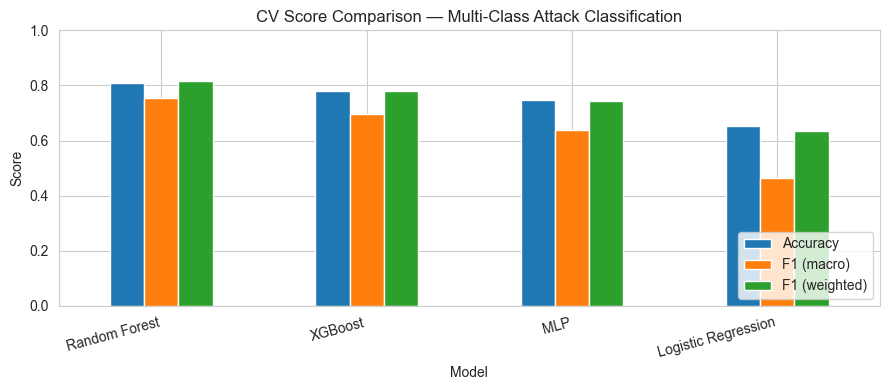

In [10]:
# Bar chart of mean CV scores — visually highlights differences between models
# across all three metrics at a glance.
figure, plot_ax = plt.subplots(figsize=(9, 4))
comparison.plot(kind='bar', ax=plot_ax)
plot_ax.set_title('CV Score Comparison — Multi-Class Attack Classification')
plot_ax.set_ylabel('Score')
plot_ax.set_ylim(0, 1)
plot_ax.set_xticklabels(comparison.index, rotation=15, ha='right')
plot_ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 7.10: Feature Importance

This section computes and visualises feature importances from both Random Forest and XGBoost to identify which features drive the multi-class classification decisions. Random Forest importances are based on mean decrease in impurity — the average reduction in node impurity across all trees that each feature produces. XGBoost importances use gain — the average improvement in the loss function that a feature's splits produce. Both are computed by fitting each model on the full training set rather than a single Cross-Validation fold, so the importances reflect a model trained on as much data as possible. Comparing the two methods is useful because impurity-based importances can be biased towards high-cardinality features, while gain-based importances directly measure predictive contribution to the boosting objective.

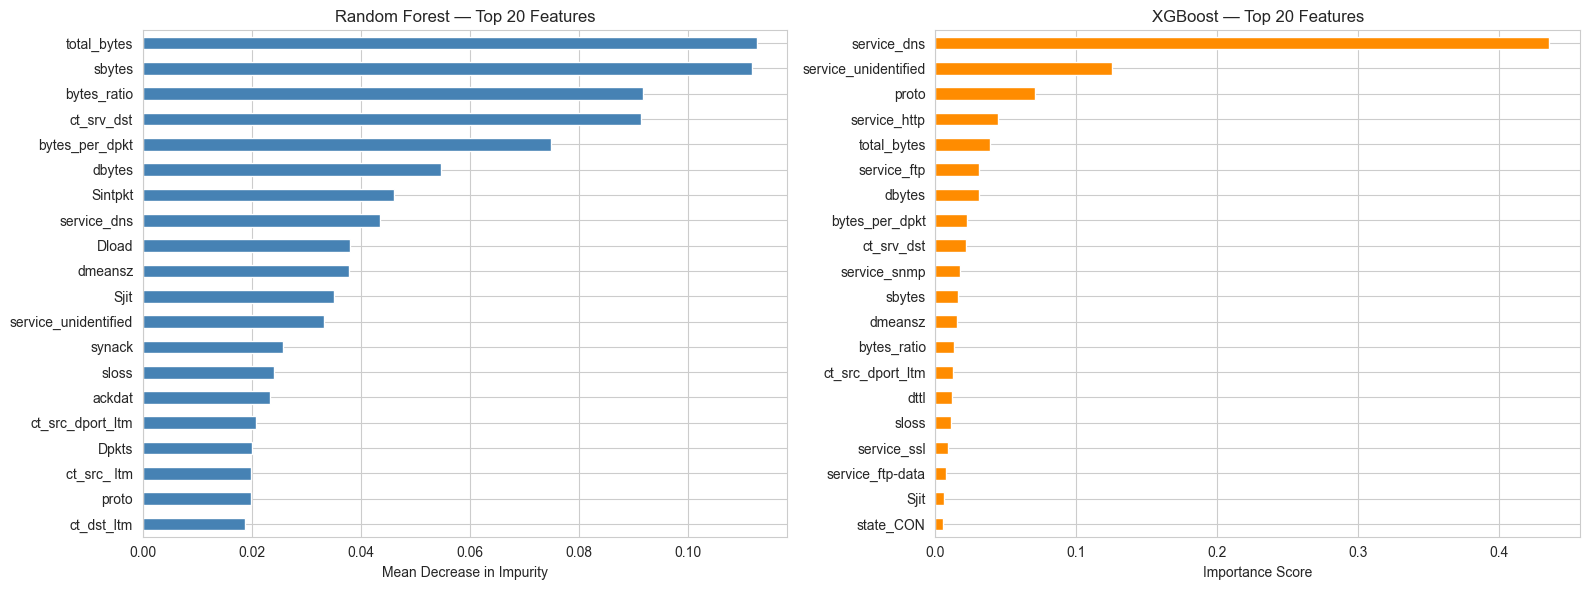

In [11]:
# Fit both models on the full training set (not just one CV fold) so that importances
# are computed from a model that has seen all available training data.
# Note: random_forest and xgboost_classifier were instantiated in sections 7.6 and 7.7 respectively.
random_forest.fit(features_train, labels_train)
xgboost_classifier.fit(features_train, labels_train)

feature_names = features_train.columns

# Random Forest importance = mean decrease in impurity (Gini) across all trees.
# Higher values mean the feature caused larger reductions in node impurity on average.
random_forest_importance = pd.Series(random_forest.feature_importances_, index=feature_names).sort_values(ascending=False)

# XGBoost importance = how often a feature is used to split across all trees (gain by default).
xgboost_importance = pd.Series(xgboost_classifier.feature_importances_, index=feature_names).sort_values(ascending=False)

TOP_N_FEATURES = 20  # only show the top 20 to keep the chart readable.

figure, subplot_axes = plt.subplots(1, 2, figsize=(16, 6))

random_forest_importance.head(TOP_N_FEATURES).plot(kind='barh', ax=subplot_axes[0], color='steelblue')
subplot_axes[0].set_title(f'Random Forest — Top {TOP_N_FEATURES} Features')
subplot_axes[0].set_xlabel('Mean Decrease in Impurity')
subplot_axes[0].invert_yaxis()  # highest importance at the top

xgboost_importance.head(TOP_N_FEATURES).plot(kind='barh', ax=subplot_axes[1], color='darkorange')
subplot_axes[1].set_title(f'XGBoost — Top {TOP_N_FEATURES} Features')
subplot_axes[1].set_xlabel('Importance Score')
subplot_axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 7.11: Evaluate Best Model on Test Set

This section evaluates the best model selected in section 7.9 on the held-out test set, which has not been used at any point during training or Cross-Validation. Evaluating on a strictly separate test set gives an unbiased estimate of how the model will perform on unseen network traffic. The test set preserves the original class distribution from the raw dataset (~87% normal, ~13% attack across categories), reflecting realistic deployment conditions rather than the balanced resampled training distribution. The reader should expect a per-class classification report showing precision, recall, and F1 for each of the nine attack categories.

In [12]:
# Random Forest is used since it performs the best based on cross-validation scores.
best_model = random_forest
best_model_name = 'Random Forest'

predicted_labels = best_model.predict(features_test)

print(f'=== {best_model_name} — Test Set Evaluation ===')

# Classification report shows per-class precision, recall, and F1 for every attack category.
# Pay close attention to recall on rare categories: Worms, Shellcode, Backdoor.
print(classification_report(labels_test, predicted_labels, target_names=CLASS_NAMES, digits=4))

=== Random Forest — Test Set Evaluation ===
                precision    recall  f1-score   support

      Analysis     0.0961    0.2419    0.1376       430
      Backdoor     0.0966    0.1194    0.1068       377
           DoS     0.3219    0.2195    0.2611      1116
      Exploits     0.8479    0.8333    0.8405      5494
       Fuzzers     0.8977    0.8897    0.8937      4153
       Generic     0.9314    0.8801    0.9050      3735
Reconnaissance     0.8046    0.7743    0.7891      2047
     Shellcode     0.6842    0.7075    0.6957       294
         Worms     0.5294    0.8438    0.6506        32

      accuracy                         0.7792     17678
     macro avg     0.5789    0.6121    0.5867     17678
  weighted avg     0.8014    0.7792    0.7886     17678



### 7.11.1: Confusion Matrix

A normalised confusion matrix reveals which attack categories the best model confuses with one another. Each row represents a true class and each column a predicted class; values on the diagonal are correct classifications. Row-normalisation is used so that rare categories (such as Worms or Analysis) are as readable as common ones (such as Normal). Off-diagonal cells highlight the specific class pairs that cause the most errors, which guides further investigation and potential remediation strategies.

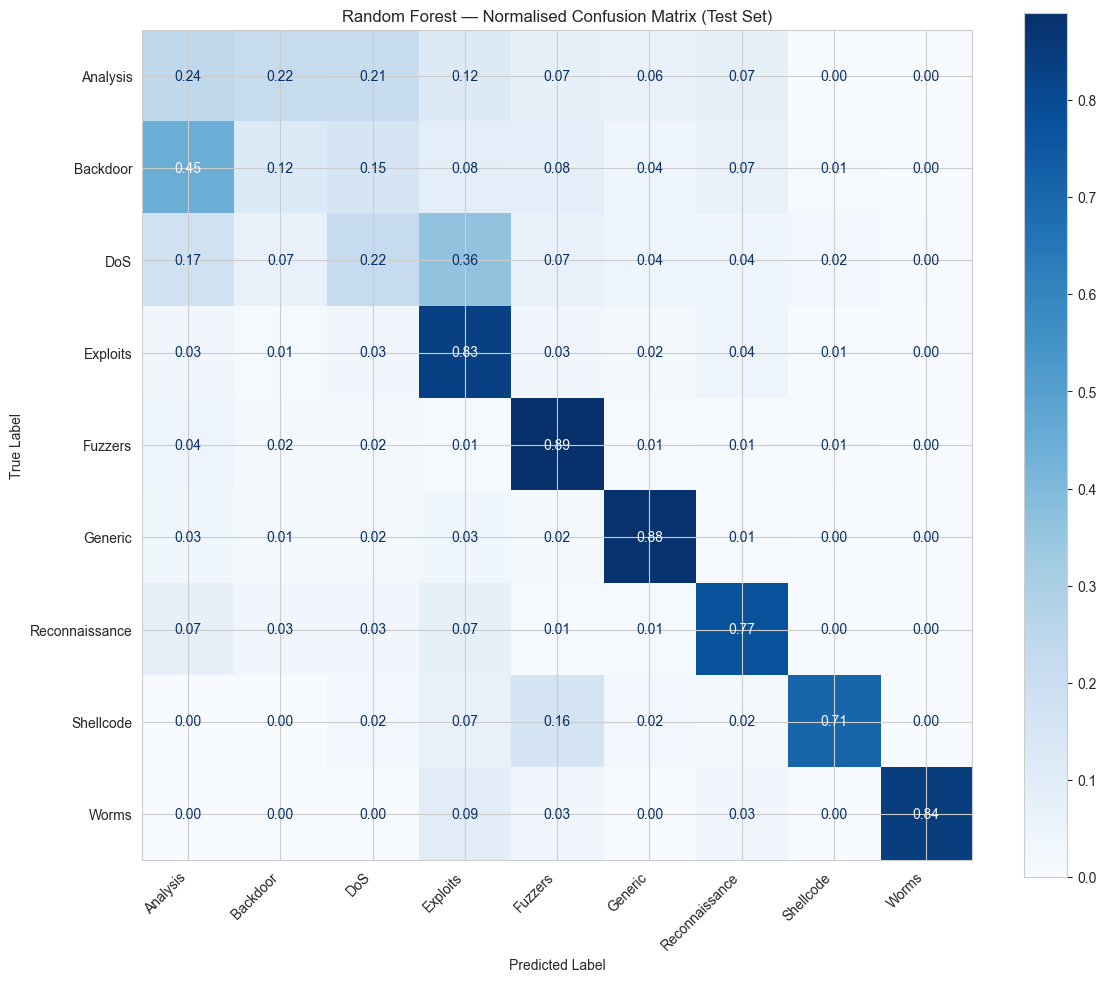

In [13]:
# Normalised confusion matrix — each row shows the proportion of true samples from that
# class assigned to each predicted class. Values along the diagonal are correct
# classifications; off-diagonal values are misclassifications.
# Normalisation makes rare categories readable alongside large ones.
class_labels = sorted(labels_test.unique())
conf_matrix = confusion_matrix(labels_test, predicted_labels, labels=class_labels, normalize='true')
conf_matrix_display = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=CLASS_NAMES)

figure, plot_ax = plt.subplots(figsize=(12, 10))
conf_matrix_display.plot(ax=plot_ax, colorbar=True, cmap='Blues', values_format='.2f')
plot_ax.set_title(f'{best_model_name} — Normalised Confusion Matrix (Test Set)')
plot_ax.set_xlabel('Predicted Label')
plot_ax.set_ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 7.9.1: Cross-Validation Fold Score Distribution

While section 7.9 reports mean scores across folds, this section visualises the distribution of per-fold scores using box plots. A narrow spread across folds indicates stable model performance, while a wide spread suggests the model is sensitive to which training samples end up in which fold. This is particularly important for a resampled multi-class dataset where fold composition can influence scores on rare attack categories. The reader should expect one box plot per model per metric, with the interquartile range indicating the variability of scores across the five folds.

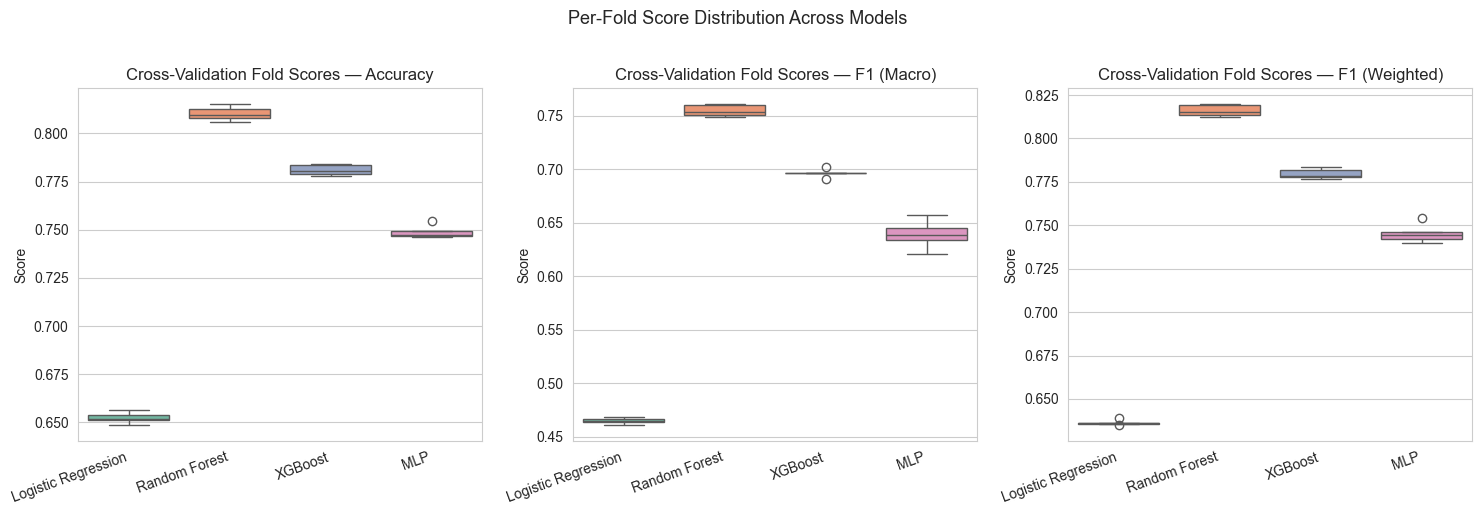

In [14]:
# Build a long-form DataFrame of per-fold scores for box-plot visualisation.
# Each row contains the model name, metric name, and score for one fold.
fold_score_rows = []
metric_display_names = {
    'test_accuracy': 'Accuracy',
    'test_f1_macro': 'F1 (Macro)',
    'test_f1_weighted': 'F1 (Weighted)',
}

for model_name, results in cross_validation_results.items():
    for metric_key, metric_label in metric_display_names.items():
        for fold_score in results[metric_key]:
            fold_score_rows.append({
                'Model': model_name,
                'Metric': metric_label,
                'Score': fold_score,
            })

fold_scores_data = pd.DataFrame(fold_score_rows)

# One subplot per metric so each box plot shares the same y-axis scale.
figure, subplot_axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

for idx, metric_label in enumerate(metric_display_names.values()):
    metric_data = fold_scores_data[fold_scores_data['Metric'] == metric_label]
    sns.boxplot(
        data=metric_data,
        x='Model',
        y='Score',
        hue='Model',
        legend=False,
        ax=subplot_axes[idx],
        palette='Set2',
    )
    subplot_axes[idx].set_title(f'Cross-Validation Fold Scores — {metric_label}')
    subplot_axes[idx].set_xlabel('')
    subplot_axes[idx].set_ylabel('Score')
    plt.setp(subplot_axes[idx].get_xticklabels(), rotation=20, ha='right')

plt.suptitle('Per-Fold Score Distribution Across Models', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 7.10.1: Permutation Importance

Permutation importance measures how much the model's macro F1 score drops when a single feature's values are randomly shuffled, breaking its relationship with the target. Unlike the impurity-based importances shown in section 7.10, permutation importance is computed on the test set and is not biased towards high-cardinality continuous features. Comparing the two methods helps identify features whose impurity-based importance may be inflated relative to their true predictive contribution. A subsample of 5,000 test rows is used to keep computation time manageable.

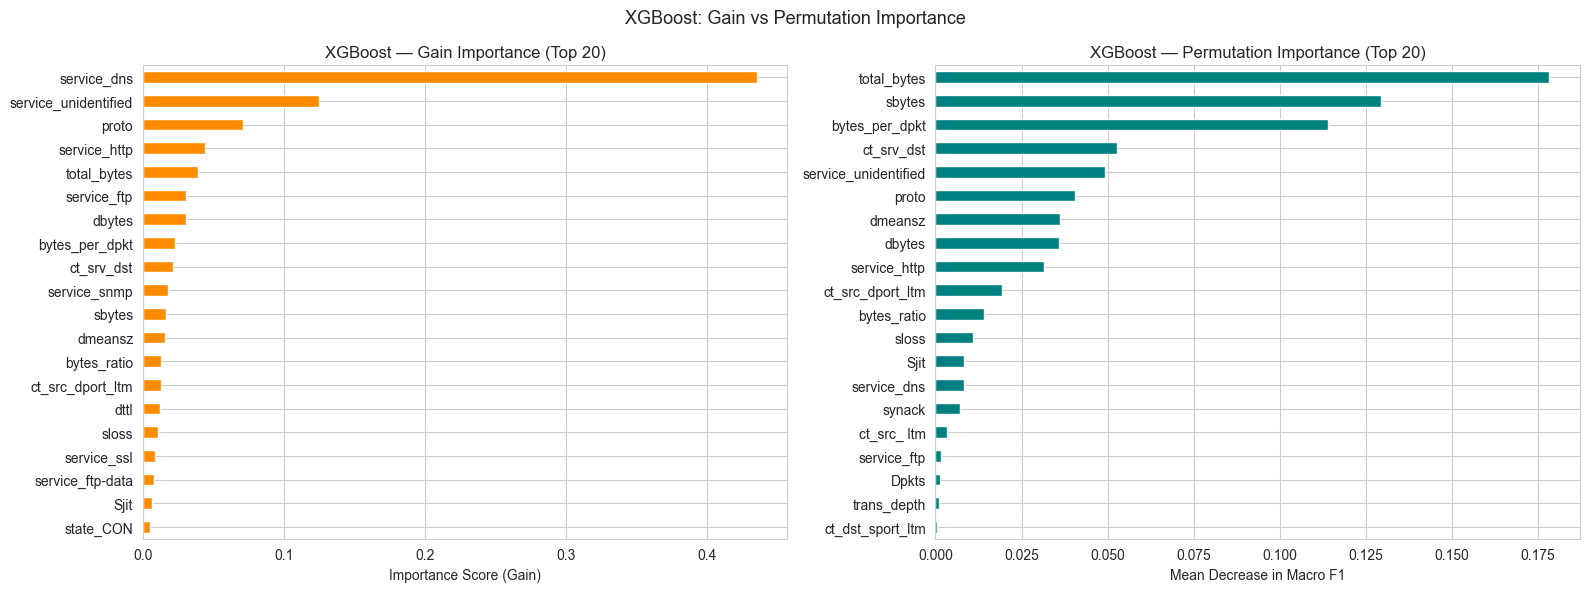

In [15]:
# Subsample 5,000 test rows to limit permutation importance computation time.
rng_perm = np.random.default_rng(42)
perm_sample_idx = rng_perm.choice(len(features_test), size=5000, replace=False)
features_test_perm = features_test.iloc[perm_sample_idx]
labels_test_perm = labels_test.iloc[perm_sample_idx]

# Compute permutation importance on XGBoost using macro F1 as the scoring function.
# n_repeats=10 shuffles each feature 10 times and averages the score drop for stability.
perm_importance_result = permutation_importance(
    xgboost_classifier,
    features_test_perm,
    labels_test_perm,
    scoring='f1_macro',
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
)

perm_importance_series = pd.Series(
    perm_importance_result.importances_mean,
    index=features_train.columns,
).sort_values(ascending=False)

# Side-by-side comparison: XGBoost gain importance vs permutation importance.
figure, subplot_axes = plt.subplots(1, 2, figsize=(16, 6))

xgboost_importance.head(TOP_N_FEATURES).plot(
    kind='barh', ax=subplot_axes[0], color='darkorange'
)
subplot_axes[0].set_title(f'XGBoost — Gain Importance (Top {TOP_N_FEATURES})')
subplot_axes[0].set_xlabel('Importance Score (Gain)')
subplot_axes[0].invert_yaxis()

perm_importance_series.head(TOP_N_FEATURES).plot(
    kind='barh', ax=subplot_axes[1], color='teal'
)
subplot_axes[1].set_title(f'XGBoost — Permutation Importance (Top {TOP_N_FEATURES})')
subplot_axes[1].set_xlabel('Mean Decrease in Macro F1')
subplot_axes[1].invert_yaxis()

plt.suptitle('XGBoost: Gain vs Permutation Importance', fontsize=13)
plt.tight_layout()
plt.show()

### 7.11.2: Per-Class ROC Curves

Multi-class ROC curves are computed using a one-vs-rest strategy: for each attack category, the model's predicted probability for that class is treated as a binary score. A separate ROC curve and Area Under the Curve (AUC) value is then computed for that class versus all others combined. Plotting all curves together on one figure shows which categories are easiest to discriminate and which are hardest. A perfect classifier would achieve AUC = 1.0 for all categories; a random classifier would lie on the diagonal.

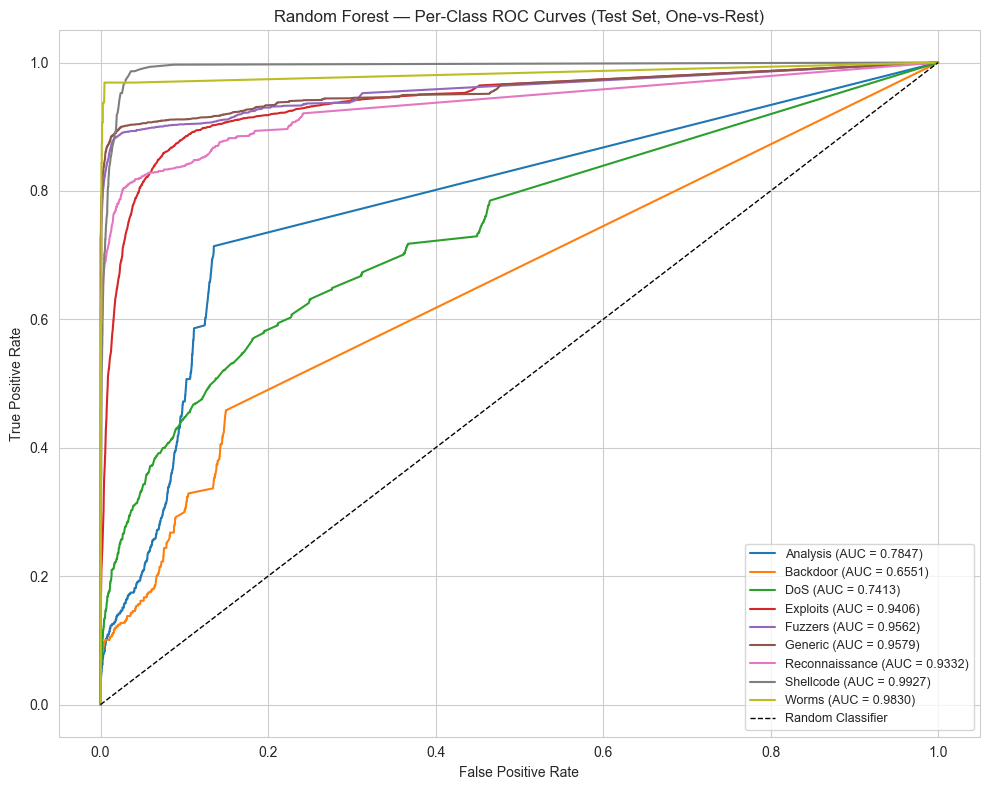

In [16]:
# Get the ordered class list from the best model so probability columns align with labels.
class_labels_ordered = best_model.classes_

# Binarise labels one-vs-rest for per-class ROC computation.
labels_test_binarized = label_binarize(labels_test, classes=class_labels_ordered)

# Predict class probabilities on the test set.
test_probabilities = best_model.predict_proba(features_test)

# Compute ROC curve and AUC for each class.
figure, plot_ax = plt.subplots(figsize=(10, 8))

for class_idx, class_int in enumerate(class_labels_ordered):
    class_name = ATTACK_CAT_MAPPING[class_int]
    fpr, tpr, _ = roc_curve(
        labels_test_binarized[:, class_idx],
        test_probabilities[:, class_idx],
    )
    auc_score = roc_auc_score(
        labels_test_binarized[:, class_idx],
        test_probabilities[:, class_idx],
    )
    plot_ax.plot(fpr, tpr, label=f'{class_name} (AUC = {auc_score:.4f})')

# Diagonal reference line representing a random classifier.
plot_ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plot_ax.set_title(f'{best_model_name} — Per-Class ROC Curves (Test Set, One-vs-Rest)')
plot_ax.set_xlabel('False Positive Rate')
plot_ax.set_ylabel('True Positive Rate')
plot_ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

### 7.11.3: Predicted Score Distribution

For each test sample, the maximum predicted probability across all classes represents the model's confidence in its top-ranked prediction. This section plots that confidence score split by whether the prediction was correct or incorrect. A well-calibrated, confident model should show high probabilities concentrated among correct predictions and lower probabilities for incorrect ones. Wide overlap between the two groups indicates that the model assigns similarly high confidence to both correct and incorrect predictions — a sign of overconfidence.

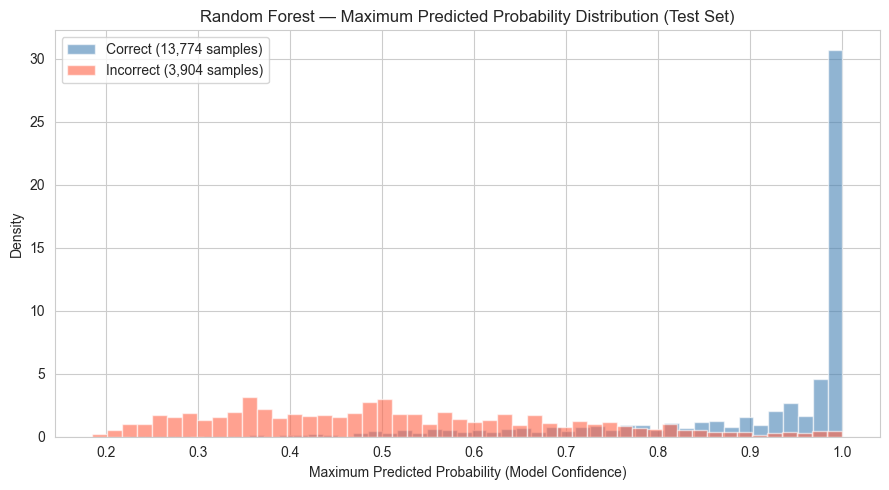

Median confidence — Correct predictions:   0.9800
Median confidence — Incorrect predictions: 0.4921


In [17]:
# Maximum predicted probability for each test sample (model confidence in top prediction).
max_proba = best_model.predict_proba(features_test).max(axis=1)

# Boolean mask: True where the predicted label matches the true label.
correct_mask = predicted_labels == labels_test.values

figure, plot_ax = plt.subplots(figsize=(9, 5))

# Histogram for correct predictions.
plot_ax.hist(
    max_proba[correct_mask],
    bins=50,
    alpha=0.6,
    color='steelblue',
    label=f'Correct ({correct_mask.sum():,} samples)',
    density=True,
)

# Histogram for incorrect predictions overlaid on the same axis.
plot_ax.hist(
    max_proba[~correct_mask],
    bins=50,
    alpha=0.6,
    color='tomato',
    label=f'Incorrect ({(~correct_mask).sum():,} samples)',
    density=True,
)

plot_ax.set_title(f'{best_model_name} — Maximum Predicted Probability Distribution (Test Set)')
plot_ax.set_xlabel('Maximum Predicted Probability (Model Confidence)')
plot_ax.set_ylabel('Density')
plot_ax.legend()
plt.tight_layout()
plt.show()

print(f'Median confidence — Correct predictions:   {np.median(max_proba[correct_mask]):.4f}')
print(f'Median confidence — Incorrect predictions: {np.median(max_proba[~correct_mask]):.4f}')

## 7.12: Multi-Class Precision-Recall Analysis

Precision-Recall curves are computed for each attack category using a one-vs-rest approach. Unlike ROC curves, Precision-Recall curves are sensitive to class imbalance and better reflect performance on rare categories — a model that achieves high recall for Worms or Analysis at the cost of many false alarms will be penalised more clearly on a Precision-Recall curve than on a ROC curve. This is because the Precision-Recall curve plots precision (how many positives are correct) against recall (how many true positives are found), whereas the ROC curve's false-positive rate denominator is dominated by the large number of true negatives in an imbalanced dataset. This section plots per-class Precision-Recall curves for the best model alongside the macro and weighted average precision scores to summarise overall performance.

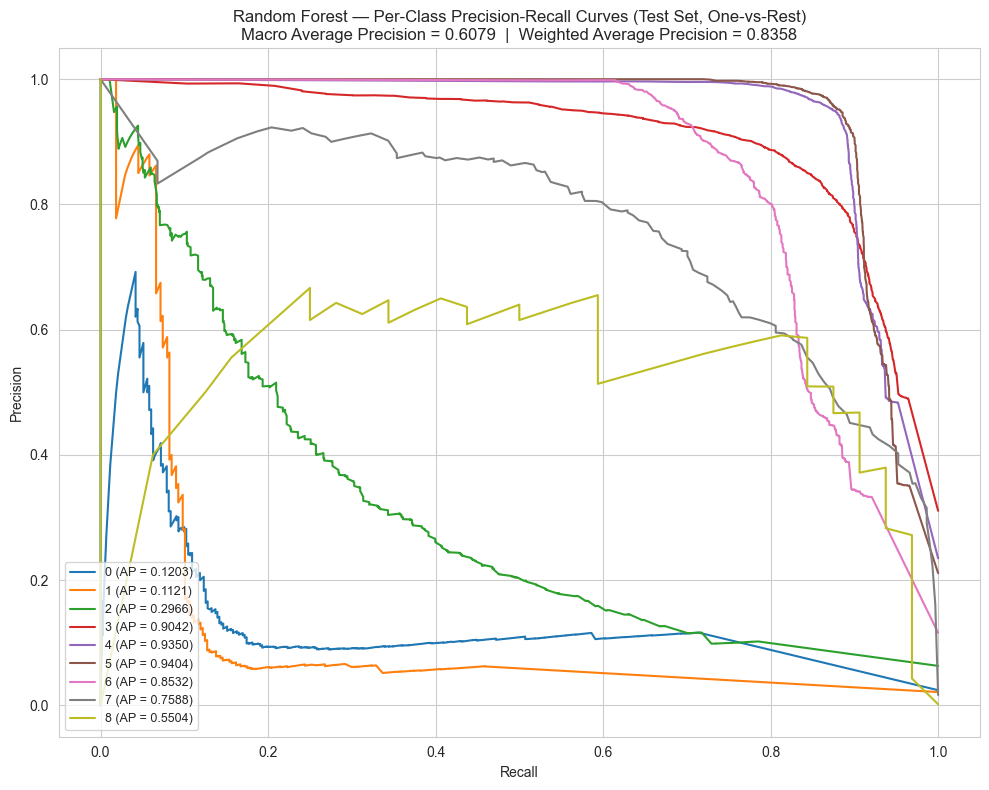

Macro Average Precision:    0.6079
Weighted Average Precision: 0.8358


In [18]:
# Compute per-class Precision-Recall curves using predicted probabilities (one-vs-rest).
figure, plot_ax = plt.subplots(figsize=(10, 8))

for class_idx, class_name in enumerate(class_labels_ordered):
    precision_vals, recall_vals, _ = precision_recall_curve(
        labels_test_binarized[:, class_idx],
        test_probabilities[:, class_idx],
    )
    ap_score = average_precision_score(
        labels_test_binarized[:, class_idx],
        test_probabilities[:, class_idx],
    )
    plot_ax.plot(recall_vals, precision_vals, label=f'{class_name} (AP = {ap_score:.4f})')

# Macro and weighted average precision scores summarise overall PR performance.
macro_ap = average_precision_score(
    labels_test_binarized,
    test_probabilities,
    average='macro',
)
weighted_ap = average_precision_score(
    labels_test_binarized,
    test_probabilities,
    average='weighted',
)

plot_ax.set_title(
    f'{best_model_name} — Per-Class Precision-Recall Curves (Test Set, One-vs-Rest)\n'
    f'Macro Average Precision = {macro_ap:.4f}  |  Weighted Average Precision = {weighted_ap:.4f}'
)
plot_ax.set_xlabel('Recall')
plot_ax.set_ylabel('Precision')
plot_ax.legend(loc='lower left', fontsize=9)
plt.tight_layout()
plt.show()

print(f'Macro Average Precision:    {macro_ap:.4f}')
print(f'Weighted Average Precision: {weighted_ap:.4f}')

### 7.12.1: Per-Class Average Precision — All Models

This section extends the Precision-Recall analysis by computing the macro-averaged precision score for all four models. The Logistic Regression and Multi-Layer Perceptron models are fitted on the full training set here (Random Forest and XGBoost were already fitted in section 7.10). A bar chart then places all four models side-by-side so the relative precision capability of each architecture is immediately visible. Average Precision summarises the area under the Precision-Recall curve in a single number, making it a compact and comparable summary metric.

=== Macro Average Precision — All Models ===
XGBoost                   : 0.6339
Random Forest             : 0.6079
Multi-Layer Perceptron    : 0.5913
Logistic Regression       : 0.4582


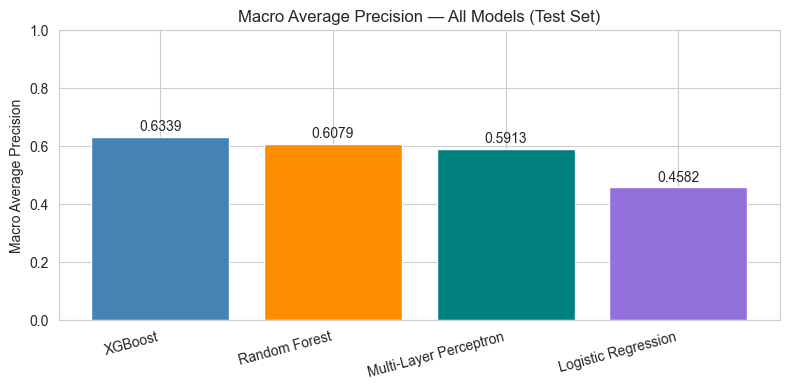

In [19]:
# Fit Logistic Regression and MLP on the full training set so predict_proba is available.
# random_forest and xgboost_classifier are already fitted from section 7.10.
logistic_regression.fit(features_train, labels_train)
multilayer_perceptron.fit(features_train, labels_train)

# Build a list of (display name, fitted model) pairs for a uniform loop.
all_models = [
    ('Logistic Regression', logistic_regression),
    ('Random Forest', random_forest),
    ('XGBoost', xgboost_classifier),
    ('Multi-Layer Perceptron', multilayer_perceptron),
]

# Compute macro average precision for each model.
model_macro_ap_scores = {}
for model_display_name, model_instance in all_models:
    model_probas = model_instance.predict_proba(features_test)
    # label_binarize uses the model's class order to align probability columns correctly.
    model_labels_binarized = label_binarize(labels_test, classes=model_instance.classes_)
    model_macro_ap_scores[model_display_name] = average_precision_score(
        model_labels_binarized,
        model_probas,
        average='macro',
    )

print('=== Macro Average Precision — All Models ===')
for name, score in sorted(model_macro_ap_scores.items(), key=lambda x: x[1], reverse=True):
    print(f'{name:<26s}: {score:.4f}')

# Bar chart comparison.
figure, plot_ax = plt.subplots(figsize=(8, 4))
model_names_sorted = sorted(model_macro_ap_scores, key=model_macro_ap_scores.get, reverse=True)
ap_values_sorted = [model_macro_ap_scores[n] for n in model_names_sorted]
plot_ax.bar(model_names_sorted, ap_values_sorted, color=['steelblue', 'darkorange', 'teal', 'mediumpurple'])
plot_ax.set_title('Macro Average Precision — All Models (Test Set)')
plot_ax.set_ylabel('Macro Average Precision')
plot_ax.set_ylim(0, 1)
plt.setp(plot_ax.get_xticklabels(), rotation=15, ha='right')
for bar_patch, ap_val in zip(plot_ax.patches, ap_values_sorted):
    plot_ax.text(
        bar_patch.get_x() + bar_patch.get_width() / 2,
        bar_patch.get_height() + 0.01,
        f'{ap_val:.4f}',
        ha='center', va='bottom', fontsize=10,
    )
plt.tight_layout()
plt.show()

### 7.12.2: Cross-Model Disagreement Analysis

When two strong models disagree on a prediction, the disagreement itself is informative: it may indicate ambiguous traffic patterns, feature overlap between categories, or the boundary regions of each model's decision space. This section compares Random Forest and XGBoost predictions on the test set, counts the total disagreements, and then breaks down those disagreements by true category. A stacked bar chart shows, for each true category among the disagreements, how many times Random Forest was correct versus XGBoost was correct versus both were wrong. This highlights which attack types cause systematic disagreement between the two models.

Total test samples:        17,678
Disagreements (RF vs XGB): 2,180 (12.33%)

=== Disagreement Breakdown by True Category ===
Outcome         Random Forest Correct  XGBoost Correct  Both Incorrect
True Category                                                         
Exploits                          204              161             188
Generic                           148               32             154
DoS                               115               36             174
Fuzzers                            51               26             173
Reconnaissance                     38               39             158
Shellcode                           6               44               3
Backdoor                            5               11             122
Worms                               2                0               0
Analysis                            1              274              15


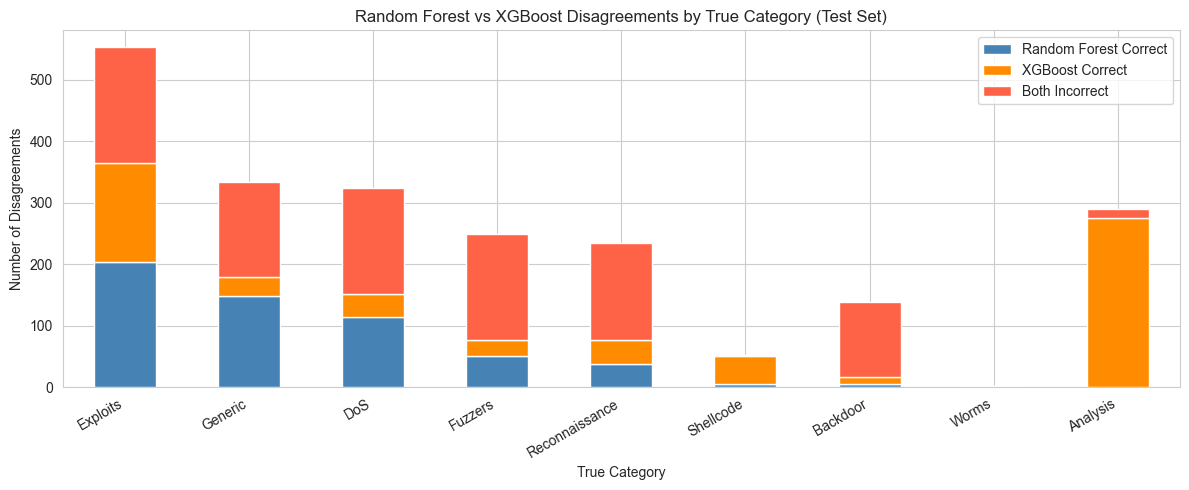

In [20]:
# Predict from both models on the test set.
random_forest_predictions = random_forest.predict(features_test)
xgboost_predictions = xgboost_classifier.predict(features_test)
true_labels_array = labels_test.values

# Identify disagreement rows: where the two models predict different classes.
disagreement_mask = random_forest_predictions != xgboost_predictions
total_disagreements = disagreement_mask.sum()

print(f'Total test samples:        {len(true_labels_array):,}')
print(f'Disagreements (RF vs XGB): {total_disagreements:,} '
      f'({100 * total_disagreements / len(true_labels_array):.2f}%)')

# For each disagreement, classify the outcome into three buckets:
# "Random Forest Correct" — RF matched the true label, XGBoost did not
# "XGBoost Correct"       — XGBoost matched the true label, RF did not
# "Both Incorrect"        — neither model matched the true label
disagree_true = true_labels_array[disagreement_mask]
disagree_rf = random_forest_predictions[disagreement_mask]
disagree_xgb = xgboost_predictions[disagreement_mask]

rf_correct_mask = disagree_rf == disagree_true
xgb_correct_mask = disagree_xgb == disagree_true

outcome_labels = np.where(
    rf_correct_mask,
    'Random Forest Correct',
    np.where(xgb_correct_mask, 'XGBoost Correct', 'Both Incorrect'),
)

# Map integer true labels to category names for readable display.
disagree_true_names = [ATTACK_CAT_MAPPING[x] for x in disagree_true]

# Build a DataFrame for grouped counting.
disagreement_data = pd.DataFrame({
    'True Category': disagree_true_names,
    'Outcome': outcome_labels,
})

# Pivot to a wide format: rows = true category, columns = outcome bucket.
disagree_pivot = (
    disagreement_data.groupby(['True Category', 'Outcome'])
    .size()
    .unstack(fill_value=0)
)

# Ensure all three columns are present even if one outcome has zero entries.
for col in ['Random Forest Correct', 'XGBoost Correct', 'Both Incorrect']:
    if col not in disagree_pivot.columns:
        disagree_pivot[col] = 0

disagree_pivot = disagree_pivot[['Random Forest Correct', 'XGBoost Correct', 'Both Incorrect']]
disagree_pivot = disagree_pivot.sort_values('Random Forest Correct', ascending=False)

print('\n=== Disagreement Breakdown by True Category ===')
print(disagree_pivot.to_string())

# Stacked bar chart: each bar = one true category, stacked by outcome bucket.
figure, plot_ax = plt.subplots(figsize=(12, 5))
disagree_pivot.plot(
    kind='bar',
    stacked=True,
    ax=plot_ax,
    color=['steelblue', 'darkorange', 'tomato'],
)
plot_ax.set_title('Random Forest vs XGBoost Disagreements by True Category (Test Set)')
plot_ax.set_xlabel('True Category')
plot_ax.set_ylabel('Number of Disagreements')
plot_ax.set_xticklabels(disagree_pivot.index, rotation=30, ha='right')
plot_ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

## 7.13: XGBoost Hyperparameter Tuning

The default XGBoost configuration used in section 7.7 was a reasonable starting point but was not optimised for this specific dataset and class distribution. This section uses `RandomizedSearchCV` to explore 30 random combinations of key hyperparameters, scored by macro F1 on the training set with 3-fold cross-validation. The goal is to determine whether tuning can improve performance on rare attack categories, which are most sensitive to changes in tree depth, learning rate, and regularisation. The best configuration found is then evaluated on the held-out test set with a full classification report.

In [21]:
# Define the hyperparameter search space for XGBoost.
# Each key maps to a list of candidate values that RandomizedSearchCV samples from.
xgboost_param_distributions = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 4, 5, 6, 7, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5, 7],
    'gamma': [0, 0.1, 0.3, 0.5],
}

# XGBClassifier base estimator for the search.
xgboost_for_search = xgb.XGBClassifier(
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss',
    verbosity=0,
)

# RandomizedSearchCV samples n_iter=30 random combinations, each evaluated by 3-fold CV.
# Scoring by f1_macro ensures rare categories influence the selection equally.
xgboost_random_search = RandomizedSearchCV(
    xgboost_for_search,
    param_distributions=xgboost_param_distributions,
    n_iter=30,
    scoring='f1_macro',
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

xgboost_random_search.fit(features_train, labels_train)

print(f'Best Cross-Validation Macro F1: {xgboost_random_search.best_score_:.4f}')
print('Best Parameters:')
for param_name, param_value in xgboost_random_search.best_params_.items():
    print(f'    {param_name}: {param_value}')

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best Cross-Validation Macro F1: 0.7397
Best Parameters:
    subsample: 0.6
    n_estimators: 500
    min_child_weight: 3
    max_depth: 8
    learning_rate: 0.1
    gamma: 0.3
    colsample_bytree: 0.7


In [22]:
# Extract the best estimator and evaluate it on the held-out test set.
tuned_xgboost = xgboost_random_search.best_estimator_

tuned_xgboost_predictions = tuned_xgboost.predict(features_test)

print('=== Tuned XGBoost — Test Set Evaluation ===')
print(classification_report(labels_test, tuned_xgboost_predictions, target_names=CLASS_NAMES, digits=4))

tuned_xgboost_macro_f1 = f1_score(labels_test, tuned_xgboost_predictions, average='macro')
print(f'Tuned XGBoost Test Macro F1:   {tuned_xgboost_macro_f1:.4f}')
print(f'Default XGBoost Test Macro F1: '
      f'{f1_score(labels_test, xgboost_predictions, average="macro"):.4f}')

=== Tuned XGBoost — Test Set Evaluation ===
                precision    recall  f1-score   support

      Analysis     0.1384    0.5163    0.2183       430
      Backdoor     0.1152    0.1247    0.1197       377
           DoS     0.4062    0.1998    0.2679      1116
      Exploits     0.8568    0.8269    0.8416      5494
       Fuzzers     0.9243    0.8851    0.9043      4153
       Generic     0.9430    0.8809    0.9109      3735
Reconnaissance     0.8218    0.7772    0.7989      2047
     Shellcode     0.6461    0.7823    0.7077       294
         Worms     0.4211    0.7500    0.5393        32

      accuracy                         0.7832     17678
     macro avg     0.5859    0.6381    0.5898     17678
  weighted avg     0.8208    0.7832    0.7965     17678

Tuned XGBoost Test Macro F1:   0.5898
Default XGBoost Test Macro F1: 0.5889


### 7.13.1: XGBoost Boosting Round Curve

The boosting round curve plots training and cross-validation multi-class log loss (mlogloss) against the number of boosting rounds for the tuned XGBoost model. This diagnostic reveals whether the model is still learning at the final round (suggesting more estimators could help) or whether loss has plateaued (suggesting the current count is sufficient). A widening gap between training and validation loss indicates overfitting as the number of rounds grows.

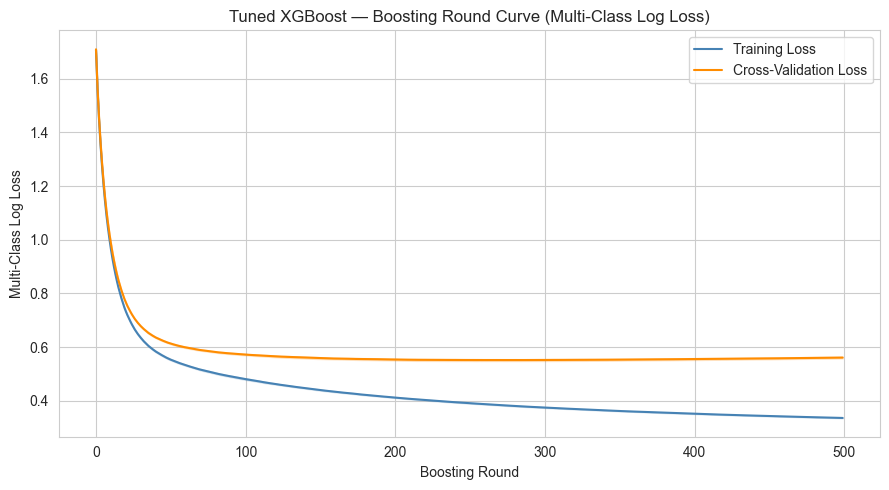

Best round (minimum CV loss): 273
CV loss at best round:        0.5517


In [23]:
# Build a DMatrix from the training data for the native XGBoost cross-validation API.
# xgb.cv requires a DMatrix and a parameter dict rather than a sklearn estimator.
# labels_train is used (not train['attack_cat']) because labels_train is already filtered
# to attack-only records and re-encoded to contiguous integers 0–8.
xgb_curve_dmatrix = xgb.DMatrix(features_train, label=labels_train)

# Extract the tuned hyperparameters from the best estimator and add mlogloss for tracking.
# get_xgb_params() does not include num_class — set it explicitly from n_classes_.
tuned_params = tuned_xgboost.get_xgb_params()
tuned_params['num_class'] = tuned_xgboost.n_classes_
tuned_params['eval_metric'] = 'mlogloss'

# Run xgb.cv to collect per-round train/validation loss.
# num_boost_round must match the tuned estimator's n_estimators.
xgb_curve_multi = xgb.cv(
    tuned_params,
    xgb_curve_dmatrix,
    num_boost_round=tuned_xgboost.n_estimators,
    nfold=3,
    stratified=True,
    seed=42,
    verbose_eval=False,
)

# Plot training vs cross-validation mlogloss across boosting rounds.
figure, plot_ax = plt.subplots(figsize=(9, 5))
plot_ax.plot(xgb_curve_multi['train-mlogloss-mean'], label='Training Loss', color='steelblue')
plot_ax.fill_between(
    range(len(xgb_curve_multi)),
    xgb_curve_multi['train-mlogloss-mean'] - xgb_curve_multi['train-mlogloss-std'],
    xgb_curve_multi['train-mlogloss-mean'] + xgb_curve_multi['train-mlogloss-std'],
    alpha=0.2, color='steelblue',
)
plot_ax.plot(xgb_curve_multi['test-mlogloss-mean'], label='Cross-Validation Loss', color='darkorange')
plot_ax.fill_between(
    range(len(xgb_curve_multi)),
    xgb_curve_multi['test-mlogloss-mean'] - xgb_curve_multi['test-mlogloss-std'],
    xgb_curve_multi['test-mlogloss-mean'] + xgb_curve_multi['test-mlogloss-std'],
    alpha=0.2, color='darkorange',
)
plot_ax.set_title('Tuned XGBoost — Boosting Round Curve (Multi-Class Log Loss)')
plot_ax.set_xlabel('Boosting Round')
plot_ax.set_ylabel('Multi-Class Log Loss')
plot_ax.legend()
plt.tight_layout()
plt.show()

best_round = xgb_curve_multi['test-mlogloss-mean'].idxmin()
print(f'Best round (minimum CV loss): {best_round}')
print(f'CV loss at best round:        {xgb_curve_multi["test-mlogloss-mean"].min():.4f}')

## 7.14: Stacking Ensemble and Final Model Selection

Stacking combines the predictions of multiple base models (Logistic Regression, Random Forest, tuned XGBoost, and Multi-Layer Perceptron) using a meta-learner (Logistic Regression) that learns which base model to trust for each type of input. Because the base models have complementary strengths — Random Forest performs best overall but XGBoost handles class boundaries differently — a stacking ensemble may achieve better macro F1 than any single model. After fitting the stacking classifier, all configurations (base models plus stacking) are compared in a single table and the best overall configuration is selected as the final model.

In [24]:
# Define the four base estimators for the stacking ensemble.
# Each tuple is (name, estimator). Using tuned_xgboost from section 7.13 so the
# XGBoost component benefits from the optimised hyperparameters.
# get_xgb_params() already includes random_state, n_jobs, and eval_metric, so all
# overrides are applied directly to the dict to avoid duplicate keyword argument errors.
tuned_xgboost_params = tuned_xgboost.get_xgb_params()
tuned_xgboost_params['num_class'] = tuned_xgboost.n_classes_
tuned_xgboost_params['eval_metric'] = 'mlogloss'
tuned_xgboost_params['verbosity'] = 0

stacking_estimators = [
    ('logistic_regression', LogisticRegression(max_iter=1000, random_state=42)),
    ('random_forest', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
    ('xgboost', xgb.XGBClassifier(**tuned_xgboost_params)),
    ('multilayer_perceptron', MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation='relu',
        max_iter=200,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1,
    )),
]

# The meta-learner (final_estimator) is a Logistic Regression that receives the base
# model probability outputs as its input features and learns to combine them optimally.
stacking_classifier = StackingClassifier(
    estimators=stacking_estimators,
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1,
    passthrough=False,
)

stacking_classifier.fit(features_train, labels_train)

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.The type of estimator is generally expected to be a classifier.However, one can pass a regressor for some use case (e.g. ordinalregression).","[('logistic_regression', ...), ('random_forest', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA classifier which will be used to combine the base estimators.The default classifier is a:class:`~sklearn.linear_model.LogisticRegression`.",LogisticRegre...ndom_state=42)
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",StratifiedKFo... shuffle=True)
,"stack_method stack_method: {'auto', 'predict_proba', 'decision_function', 'predict'}, default='auto'Methods called for each base estimator. It can be:* if 'auto', it will try to invoke, for each estimator, `'predict_proba'`, `'decision_function'` or `'predict'` in that order.* otherwise, one of `'predict_proba'`, `'decision_function'` or `'predict'`. If the method is not implemented by the estimator, it will raise an error.",'auto'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",-1
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalt

In [25]:
# Predict on the test set using the stacking ensemble.
best_final_predicted_labels = stacking_classifier.predict(features_test)
best_final_probabilities = stacking_classifier.predict_proba(features_test)

print('=== Stacking Ensemble — Test Set Evaluation ===')
print(classification_report(labels_test, best_final_predicted_labels, target_names=CLASS_NAMES, digits=4))

=== Stacking Ensemble — Test Set Evaluation ===
                precision    recall  f1-score   support

      Analysis     0.1385    0.5093    0.2178       430
      Backdoor     0.1216    0.1061    0.1133       377
           DoS     0.3612    0.2133    0.2682      1116
      Exploits     0.8423    0.8497    0.8460      5494
       Fuzzers     0.9290    0.8888    0.9084      4153
       Generic     0.9496    0.8835    0.9154      3735
Reconnaissance     0.8643    0.7748    0.8171      2047
     Shellcode     0.7837    0.6531    0.7124       294
         Worms     0.5897    0.7188    0.6479        32

      accuracy                         0.7895     17678
     macro avg     0.6200    0.6219    0.6052     17678
  weighted avg     0.8236    0.7895    0.8020     17678



In [26]:
# Compare all model configurations in a single table sorted by macro F1.
# This gives a clear picture of which configuration to deploy.
comparison_configs = {
    'Logistic Regression': logistic_regression.predict(features_test),
    'Random Forest': random_forest_predictions,
    'XGBoost (Default)': xgboost_predictions,
    'XGBoost (Tuned)': tuned_xgboost_predictions,
    'Multi-Layer Perceptron': multilayer_perceptron.predict(features_test),
    'Stacking Ensemble': best_final_predicted_labels,
}

comparison_rows = []
for config_name, config_preds in comparison_configs.items():
    comparison_rows.append({
        'Configuration': config_name,
        'Accuracy': accuracy_score(labels_test, config_preds),
        'F1 (Macro)': f1_score(labels_test, config_preds, average='macro'),
        'F1 (Weighted)': f1_score(labels_test, config_preds, average='weighted'),
    })

final_comparison = (
    pd.DataFrame(comparison_rows)
    .set_index('Configuration')
    .round(4)
    .sort_values('F1 (Macro)', ascending=False)
)

print('=== Final Model Comparison — All Configurations (Test Set) ===')
print(final_comparison.to_string())

# Set the stacking ensemble as the final best model.
best_final_model = stacking_classifier
best_final_name = 'Stacking Ensemble'

print(f'\nSelected final model: {best_final_name}')

=== Final Model Comparison — All Configurations (Test Set) ===
                        Accuracy  F1 (Macro)  F1 (Weighted)
Configuration                                              
Stacking Ensemble         0.7895      0.6052         0.8020
XGBoost (Tuned)           0.7832      0.5898         0.7965
XGBoost (Default)         0.7822      0.5889         0.7933
Random Forest             0.7792      0.5867         0.7886
Multi-Layer Perceptron    0.7634      0.5400         0.7730
Logistic Regression       0.6844      0.4257         0.6857

Selected final model: Stacking Ensemble


### 7.14.1: Bootstrap Confidence Intervals

Point estimates for accuracy and F1 scores can appear more precise than they really are, because the test set is a single sample from the broader distribution of possible network traffic. Bootstrap confidence intervals quantify this uncertainty by resampling the test set with replacement 1,000 times, computing the metric on each resample, and reporting the 2.5th and 97.5th percentiles as the 95% confidence interval. Wider intervals indicate that the metric is more sensitive to which specific samples appear in the evaluation set.

In [27]:
# Define the number of bootstrap resamples and initialise the random number generator.
N_BOOTSTRAP = 1000
rng_bootstrap = np.random.default_rng(42)

# Initialise lists to accumulate metric values across bootstrap iterations.
bootstrap_accuracy = []
bootstrap_f1_macro = []
bootstrap_f1_weighted = []

# Extract test labels and record the test set size for use in the resampling loop.
true_labels_array_final = labels_test.values
n_test_samples = len(true_labels_array_final)

# Resample with replacement 1,000 times and compute each metric on the resample.
for _ in range(N_BOOTSTRAP):
    resample_idx = rng_bootstrap.choice(n_test_samples, size=n_test_samples, replace=True)
    resampled_true = true_labels_array_final[resample_idx]
    resampled_pred = best_final_predicted_labels[resample_idx]

    # Skip draws where any class is missing — metrics would be undefined for that class.
    if len(np.unique(resampled_true)) < len(np.unique(true_labels_array_final)):
        continue

    bootstrap_accuracy.append(accuracy_score(resampled_true, resampled_pred))
    bootstrap_f1_macro.append(f1_score(resampled_true, resampled_pred, average='macro'))
    bootstrap_f1_weighted.append(f1_score(resampled_true, resampled_pred, average='weighted'))

# Report 95% confidence intervals as the 2.5th and 97.5th percentiles.
print('=== Bootstrap 95% Confidence Intervals — Stacking Ensemble (Test Set) ===')
print(f'{"Metric":<22}  {"Point Estimate":>16}  {"Lower 2.5%":>12}  {"Upper 97.5%":>12}')
print('-' * 68)

for metric_label, point_estimate, bootstrap_samples in [
    ('Accuracy', accuracy_score(true_labels_array_final, best_final_predicted_labels), bootstrap_accuracy),
    ('F1 (Macro)', f1_score(true_labels_array_final, best_final_predicted_labels, average='macro'), bootstrap_f1_macro),
    ('F1 (Weighted)', f1_score(true_labels_array_final, best_final_predicted_labels, average='weighted'), bootstrap_f1_weighted),
]:
    lower = np.percentile(bootstrap_samples, 2.5)
    upper = np.percentile(bootstrap_samples, 97.5)
    print(f'{metric_label:<22}  {point_estimate:>16.4f}  {lower:>12.4f}  {upper:>12.4f}')

=== Bootstrap 95% Confidence Intervals — Stacking Ensemble (Test Set) ===
Metric                    Point Estimate    Lower 2.5%   Upper 97.5%
--------------------------------------------------------------------
Accuracy                          0.7895        0.7835        0.7956
F1 (Macro)                        0.6052        0.5865        0.6203
F1 (Weighted)                     0.8020        0.7959        0.8084


## 7.15: SHAP Explainability

SHapley Additive exPlanations (SHAP) provides a theoretically grounded method for attributing a model's prediction to each input feature. For multi-class problems, SHAP produces one set of values per class, capturing how each feature pushes the model's output towards or away from that class. This section uses `TreeExplainer` on the XGBoost component of the stacking ensemble (the third base estimator, index 2). A beeswarm plot for the Generic class — the most prevalent attack category — shows which features most strongly drive predictions towards that category. A waterfall plot then explains a single misclassified attack sample in detail, showing the contribution of each feature to the predicted class.

In [28]:
# Subsample 2,000 test rows for SHAP computation to keep runtime manageable.
rng = np.random.default_rng(42)
shap_sample_idx = rng.choice(len(features_test), size=2000, replace=False)
features_test_shap = features_test.iloc[shap_sample_idx].reset_index(drop=True)
labels_test_shap = labels_test.iloc[shap_sample_idx].reset_index(drop=True)

# The XGBoost component is the third estimator (index 2) in the stacking ensemble.
# stacking_classifier.estimators_ holds the fitted base estimators.
xgboost_in_stack = best_final_model.estimators_[2]

# Build a TreeExplainer for the XGBoost component.
shap_explainer = shap.TreeExplainer(xgboost_in_stack)

# Compute SHAP values. For multi-class XGBoost the result is an Explanation object
# whose .values attribute has shape (n_samples, n_features, n_classes).
shap_values = shap_explainer(features_test_shap)

# xgboost_class_labels is a sorted list of integer class codes.
xgboost_class_labels = sorted(labels_train.unique())

# Find the integer code for 'Generic' and its position in the sorted class list.
# Generic is the most prevalent attack category and provides a representative beeswarm.
generic_class_int = next(k for k, v in ATTACK_CAT_MAPPING.items() if v == 'Generic')
generic_class_idx = xgboost_class_labels.index(generic_class_int)

print(f"XGBoost class order: {[ATTACK_CAT_MAPPING[c] for c in xgboost_class_labels]}")
print(f"'Generic' class index: {generic_class_idx}")
print(f"SHAP values shape: {shap_values.values.shape}")

XGBoost class order: ['Analysis', 'Backdoor', 'DoS', 'Exploits', 'Fuzzers', 'Generic', 'Reconnaissance', 'Shellcode', 'Worms']
'Generic' class index: 5
SHAP values shape: (2000, 47, 9)


=== SHAP Beeswarm — Generic Class ===


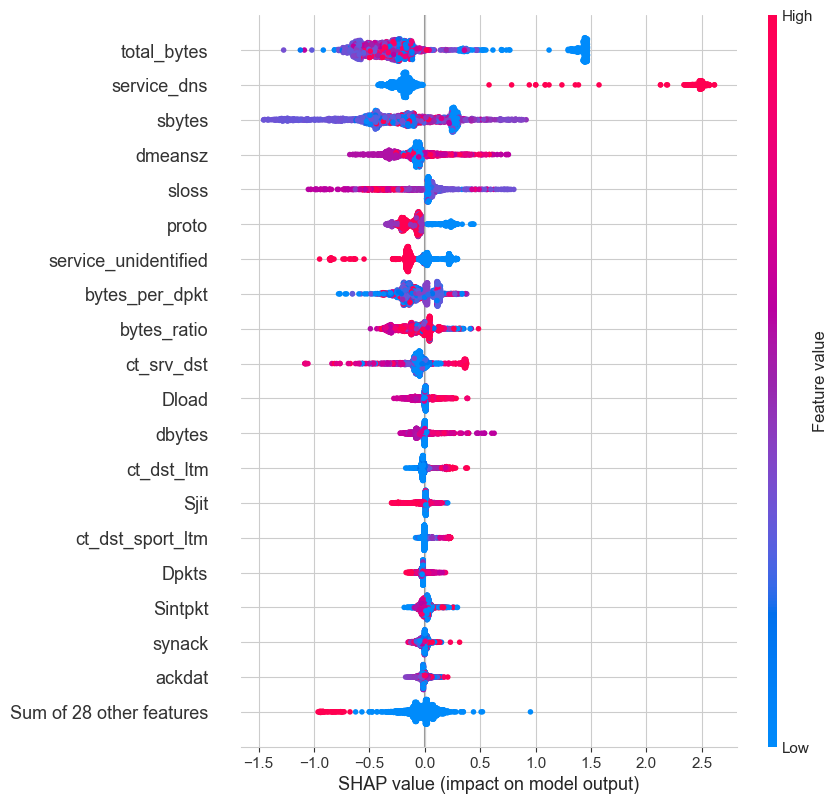

In [29]:
# Beeswarm plot for the Generic class.
# shap_values[:, :, generic_class_idx] slices the Explanation object to the Generic class,
# giving one SHAP value per sample per feature for that class only.
# Each dot is one sample; colour encodes the feature's actual value (blue=low, red=high).
print('=== SHAP Beeswarm — Generic Class ===')
shap.plots.beeswarm(shap_values[:, :, generic_class_idx], max_display=20, show=True)

Waterfall sample — Actual: DoS, Predicted: Exploits


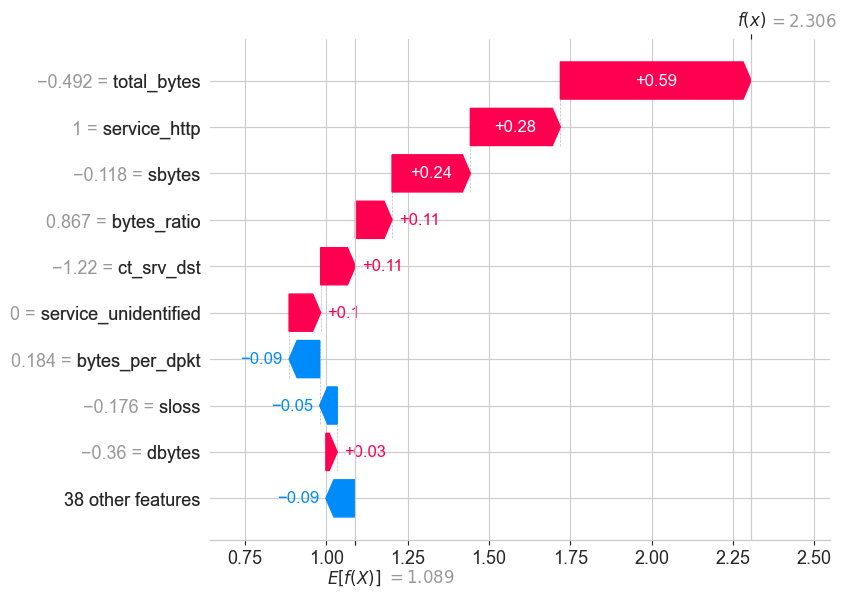

In [30]:
# Find a misclassified sample in the SHAP subsample to use for the waterfall plot.
# A misclassification is where the stacking ensemble predicted a different class than the truth.
shap_stacking_preds = best_final_model.predict(features_test_shap)
misclassified_mask_shap = shap_stacking_preds != labels_test_shap.values

# Select the first misclassified sample.
misclassified_indices = np.where(misclassified_mask_shap)[0]
waterfall_sample_idx = int(misclassified_indices[0])

# Determine the predicted class for this sample to select the correct SHAP class slice.
predicted_class_int = shap_stacking_preds[waterfall_sample_idx]
predicted_class_name = ATTACK_CAT_MAPPING[predicted_class_int]
predicted_class_idx = xgboost_class_labels.index(predicted_class_int)

actual_class_name = ATTACK_CAT_MAPPING[labels_test_shap.values[waterfall_sample_idx]]
print(f'Waterfall sample — Actual: {actual_class_name}, Predicted: {predicted_class_name}')

# Waterfall plot explains the prediction for the predicted class.
# It shows how each feature pushes the output from the base value (average prediction)
# to the final model output for this specific sample.
shap.plots.waterfall(shap_values[waterfall_sample_idx, :, predicted_class_idx], show=True)

### 7.15.1: SHAP Dependence Plots

SHAP dependence plots show, for a single feature, how that feature's SHAP value changes across its range of values. The horizontal axis is the feature value and the vertical axis is the SHAP contribution to the Generic class prediction. A smooth monotonic relationship suggests the feature has a consistent directional effect; a non-monotonic or scattered pattern indicates interaction effects or threshold behaviour. The top four features by mean absolute SHAP for the Generic class are displayed in a 2×2 grid.

Top 4 features by mean absolute SHAP (Generic class):
    total_bytes
    service_dns
    sbytes
    dmeansz


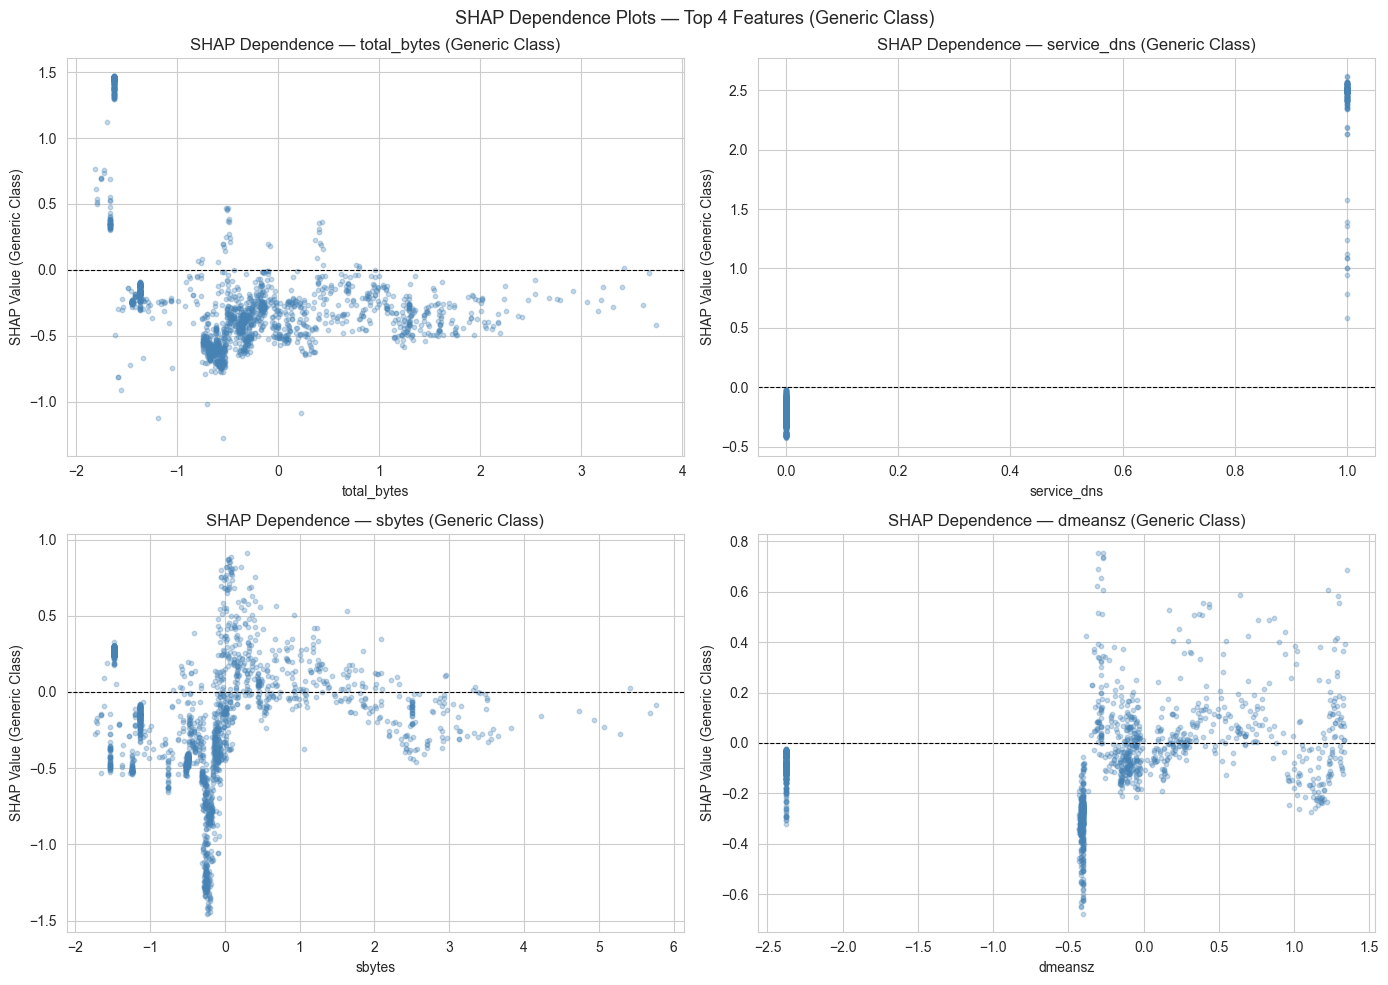

In [31]:
# Extract the Generic-class SHAP values as a plain 2D array (n_samples × n_features).
generic_class_shap_values = shap_values.values[:, :, generic_class_idx]

# Identify the top 4 features by mean absolute SHAP for the Generic class.
mean_abs_shap = np.abs(generic_class_shap_values).mean(axis=0)
top4_feature_indices = np.argsort(mean_abs_shap)[::-1][:4]
top4_feature_names = features_train.columns[top4_feature_indices].tolist()

print('Top 4 features by mean absolute SHAP (Generic class):')
for feat in top4_feature_names:
    print(f'    {feat}')

figure, subplot_axes = plt.subplots(2, 2, figsize=(14, 10))
subplot_axes_flat = subplot_axes.flatten()

for plot_idx, feature_name in enumerate(top4_feature_names):
    feature_col_idx = features_train.columns.get_loc(feature_name)
    subplot_axes_flat[plot_idx].scatter(
        features_test_shap[feature_name],
        generic_class_shap_values[:, feature_col_idx],
        alpha=0.3,
        s=10,
        color='steelblue',
    )
    subplot_axes_flat[plot_idx].axhline(0, color='black', linewidth=0.8, linestyle='--')
    subplot_axes_flat[plot_idx].set_title(f'SHAP Dependence — {feature_name} (Generic Class)')
    subplot_axes_flat[plot_idx].set_xlabel(feature_name)
    subplot_axes_flat[plot_idx].set_ylabel('SHAP Value (Generic Class)')

plt.suptitle('SHAP Dependence Plots — Top 4 Features (Generic Class)', fontsize=13)
plt.tight_layout()
plt.show()

## 7.16: LIME — Individual Prediction Explanation

Local Interpretable Model-agnostic Explanations (LIME) explains a single prediction by fitting a simple linear model in the local neighbourhood of the input sample. Unlike SHAP, LIME is model-agnostic and does not require access to the model's internals. For multi-class classification, LIME produces one explanation per class; this section shows the explanation for the predicted class of the same misclassified sample used in section 7.15. The feature weights indicate how each feature pushed the predicted class probability up or down relative to what would be expected for a typical sample.

Actual label:    DoS
Predicted label: Exploits
Showing LIME explanation for predicted class: Exploits


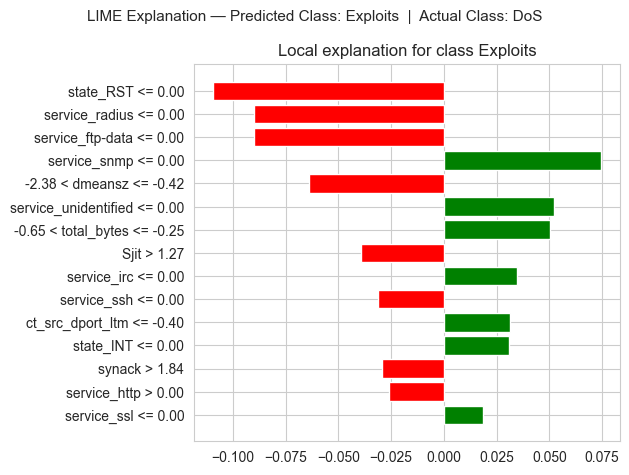

In [32]:
# class_names must be the string category names in the same order as the model's integer codes.
lime_class_names = CLASS_NAMES

# Wrap the stacking ensemble's predict_proba in a function that accepts a numpy array.
# Converting to a DataFrame with column names prevents sklearn feature name warnings.
def lime_predict_fn(X_array):
    return best_final_model.predict_proba(
        pd.DataFrame(X_array, columns=features_train.columns)
    )

# Build the LIME tabular explainer using the training data as the background distribution.
lime_explainer = lime_tabular.LimeTabularExplainer(
    training_data=features_train.values,
    feature_names=features_train.columns.tolist(),
    class_names=lime_class_names,
    mode='classification',
    random_state=42,
)

# Explain the same misclassified sample used in the SHAP waterfall plot (section 7.15).
lime_sample = features_test_shap.iloc[waterfall_sample_idx].values
lime_explanation = lime_explainer.explain_instance(
    lime_sample,
    lime_predict_fn,
    num_features=15,
    top_labels=3,
)

# Map integer predictions to names for display.
lime_predicted_int = shap_stacking_preds[waterfall_sample_idx]
predicted_class_idx_lime = lime_predicted_int  # CLASS_NAMES[i] corresponds to class code i
lime_predicted_name = CLASS_NAMES[lime_predicted_int]
lime_actual_name = CLASS_NAMES[labels_test_shap.values[waterfall_sample_idx]]

print(f'Actual label:    {lime_actual_name}')
print(f'Predicted label: {lime_predicted_name}')
print(f'Showing LIME explanation for predicted class: {lime_predicted_name}')

# Display the LIME explanation figure for the predicted class.
lime_figure = lime_explanation.as_pyplot_figure(label=predicted_class_idx_lime)
lime_figure.suptitle(
    f'LIME Explanation — Predicted Class: {lime_predicted_name}  |  Actual Class: {lime_actual_name}',
    fontsize=11,
)
plt.tight_layout()
plt.show()

## 7.17: Misclassification Analysis

Understanding which categories are most frequently misclassified — and which categories they are confused with — is essential for evaluating whether the model is safe to deploy. A model that confuses DoS with Generic traffic has different operational implications than one that confuses Worms with Normal traffic. This section profiles the misclassified samples from the final stacking ensemble: it counts misclassifications per category, lists the ten most frequent confusion pairs (true → predicted), and visualises the raw confusion counts for the five most confused categories as a heatmap.

In [33]:
# Build a DataFrame of true and predicted labels for the final model on the test set.
misclassification_data = pd.DataFrame({
    'True Category': true_labels_array_final,
    'Predicted Category': best_final_predicted_labels,
})

# Filter to only the misclassified rows.
misclassified_data = misclassification_data[
    misclassification_data['True Category'] != misclassification_data['Predicted Category']
].copy()

print(f'Total misclassifications: {len(misclassified_data):,} '
      f'({100 * len(misclassified_data) / len(true_labels_array_final):.2f}% of test set)\n')

# Count misclassifications per true category.
misclassification_counts = (
    misclassified_data['True Category']
    .value_counts()
    .rename_axis('True Category')
    .reset_index(name='Misclassification Count')
)
print('=== Misclassification Count by True Category ===')
print(misclassification_counts.to_string(index=False))

# Count the 10 most frequent confusion pairs (true → predicted).
confusion_pairs = (
    misclassified_data
    .groupby(['True Category', 'Predicted Category'])
    .size()
    .reset_index(name='Count')
    .sort_values('Count', ascending=False)
    .head(10)
    .reset_index(drop=True)
)
print('\n=== Top 10 Most Common Confusion Pairs (True → Predicted) ===')
print(confusion_pairs.to_string(index=False))

Total misclassifications: 3,721 (21.05% of test set)

=== Misclassification Count by True Category ===
 True Category  Misclassification Count
             2                      878
             3                      826
             4                      462
             6                      461
             5                      435
             1                      337
             0                      211
             7                      102
             8                        9

=== Top 10 Most Common Confusion Pairs (True → Predicted) ===
 True Category  Predicted Category  Count
             2                   3    409
             2                   0    269
             3                   0    238
             4                   0    237
             1                   0    231
             6                   0    204
             5                   0    183
             3                   6    170
             6                   3    155
             3

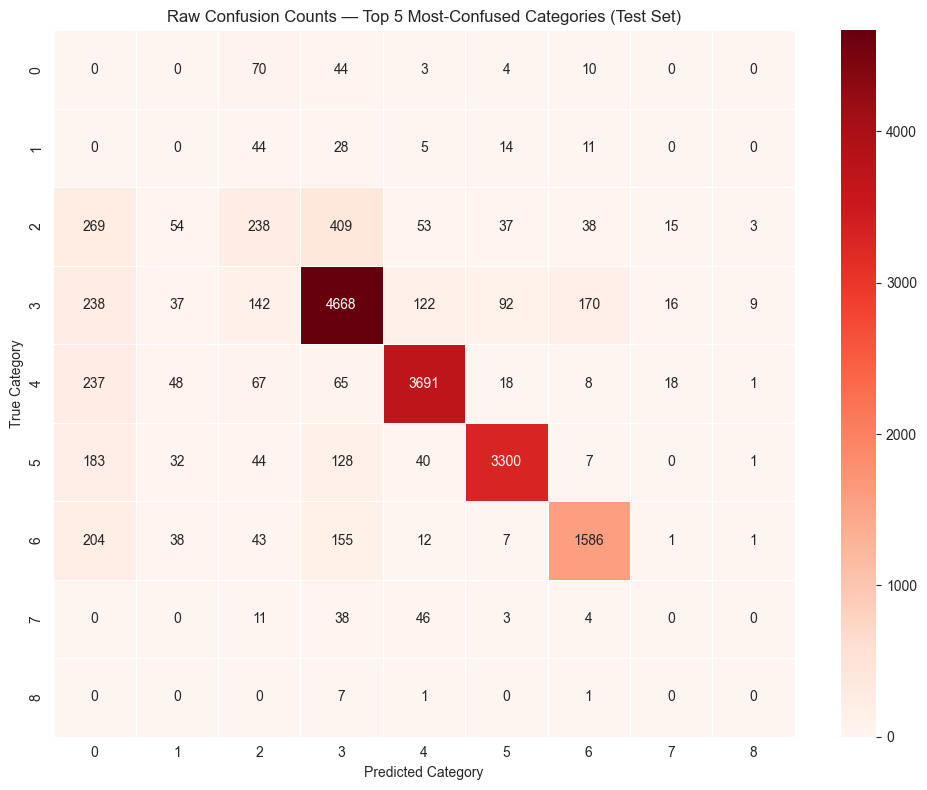

In [34]:
# Identify the 5 most-confused true categories by total misclassification count.
top5_confused_categories = misclassification_counts['True Category'].head(5).tolist()

# Build the raw (unnormalised) confusion matrix restricted to those 5 categories.
top5_mask = (
    misclassification_data['True Category'].isin(top5_confused_categories) |
    misclassification_data['Predicted Category'].isin(top5_confused_categories)
)
top5_data = misclassification_data[top5_mask]

# Get the union of true and predicted labels present in this subset for the heatmap axes.
top5_all_labels = sorted(
    set(top5_data['True Category'].unique()) | set(top5_data['Predicted Category'].unique())
)

raw_conf_matrix = confusion_matrix(
    top5_data['True Category'],
    top5_data['Predicted Category'],
    labels=top5_all_labels,
)

figure, plot_ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    pd.DataFrame(raw_conf_matrix, index=top5_all_labels, columns=top5_all_labels),
    annot=True,
    fmt='d',
    cmap='Reds',
    ax=plot_ax,
    linewidths=0.5,
)
plot_ax.set_title('Raw Confusion Counts — Top 5 Most-Confused Categories (Test Set)')
plot_ax.set_xlabel('Predicted Category')
plot_ax.set_ylabel('True Category')
plt.tight_layout()
plt.show()

## 7.18: Calibration Curve

A calibration curve compares the predicted class probability to the observed frequency of that class. A perfectly calibrated model would lie on the diagonal: when the model says a record has a 70% chance of being a DoS attack, approximately 70% of such records should actually be DoS. This section plots calibration curves for each attack category using a one-vs-rest approach on the final model's predicted probabilities. Per-class Expected Calibration Error (ECE) is also computed as a single-number summary of miscalibration — lower ECE indicates better calibration.

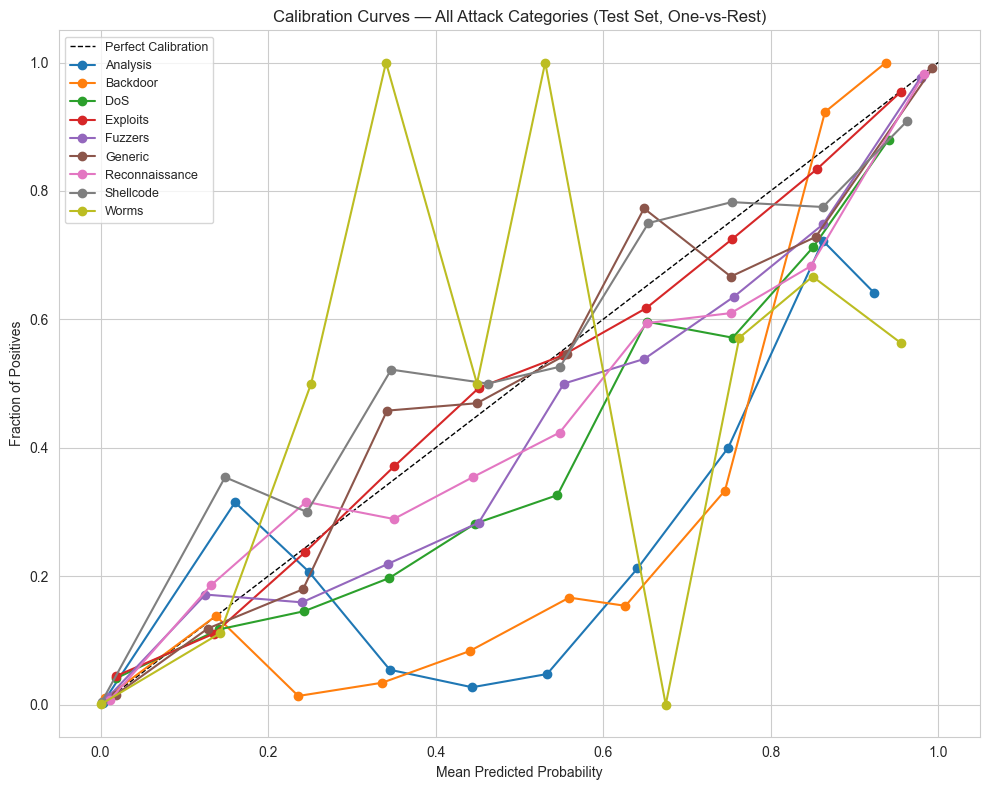

=== Expected Calibration Error (ECE) per Class ===
DoS               : 0.0292
Analysis          : 0.0248
Exploits          : 0.0205
Reconnaissance    : 0.0122
Backdoor          : 0.0105
Fuzzers           : 0.0102
Generic           : 0.0057
Shellcode         : 0.0045
Worms             : 0.0010


In [35]:
# Get the ordered class list from the final model for aligning probability columns.
final_model_classes = best_final_model.classes_

# Binarise test labels one-vs-rest for per-class calibration curves.
labels_test_binarized_final = label_binarize(labels_test, classes=final_model_classes)

N_CALIBRATION_BINS = 10

figure, plot_ax = plt.subplots(figsize=(10, 8))

# Diagonal reference line representing perfect calibration.
plot_ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Perfect Calibration')

ece_per_class = {}
for class_idx, class_int in enumerate(final_model_classes):
    class_name = ATTACK_CAT_MAPPING[class_int]
    true_binary = labels_test_binarized_final[:, class_idx]
    predicted_proba_class = best_final_probabilities[:, class_idx]

    fraction_of_positives, mean_predicted_value = calibration_curve(
        true_binary,
        predicted_proba_class,
        n_bins=N_CALIBRATION_BINS,
        strategy='uniform',
    )
    plot_ax.plot(mean_predicted_value, fraction_of_positives, marker='o', label=class_name)

    # Compute ECE: weighted average of |predicted probability - observed frequency|.
    bin_edges = np.linspace(0, 1, N_CALIBRATION_BINS + 1)
    ece_value = 0.0
    for bin_low, bin_high, frac_pos, mean_pred in zip(
        bin_edges[:-1], bin_edges[1:], fraction_of_positives, mean_predicted_value
    ):
        bin_mask = (predicted_proba_class >= bin_low) & (predicted_proba_class < bin_high)
        bin_weight = bin_mask.sum() / len(predicted_proba_class)
        ece_value += bin_weight * abs(mean_pred - frac_pos)
    ece_per_class[class_name] = ece_value

plot_ax.set_title('Calibration Curves — All Attack Categories (Test Set, One-vs-Rest)')
plot_ax.set_xlabel('Mean Predicted Probability')
plot_ax.set_ylabel('Fraction of Positives')
plot_ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

print('=== Expected Calibration Error (ECE) per Class ===')
for class_name, ece_val in sorted(ece_per_class.items(), key=lambda x: x[1], reverse=True):
    print(f'{class_name:<18}: {ece_val:.4f}')

## 7.19: Learning Curves

A learning curve plots training and cross-validation macro F1 against the number of training samples used. It diagnoses whether the model is in a high-bias regime (both curves plateau at a low score — adding data will not help) or a high-variance regime (training score is much higher than cross-validation score — more data or regularisation would help). For a dataset of this size, a learning curve also indicates at what sample count the model's performance stops improving significantly, which informs whether collecting additional labelled data would be worthwhile.

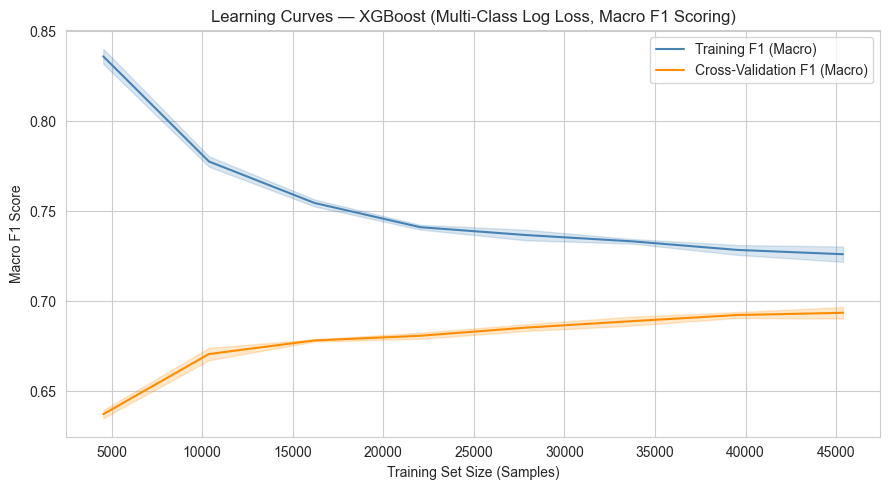

In [36]:
# Use a fresh XGBoost classifier with eval_metric='mlogloss' for the learning curve.
# Reusing the fitted xgboost_classifier is not appropriate here because learning_curve
# refits the estimator at each training set size.
xgboost_for_learning_curve = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss',
    verbosity=0,
)

# train_sizes defines the fractions of the training set to use at each step.
train_sizes_fractions = np.linspace(0.1, 1.0, 8)

train_sizes_abs, train_scores, val_scores = learning_curve(
    xgboost_for_learning_curve,
    features_train,
    labels_train,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring='f1_macro',
    train_sizes=train_sizes_fractions,
    n_jobs=-1,
)

# Average and standard deviation across folds for each training set size.
train_scores_mean = train_scores.mean(axis=1)
train_scores_std = train_scores.std(axis=1)
val_scores_mean = val_scores.mean(axis=1)
val_scores_std = val_scores.std(axis=1)

figure, plot_ax = plt.subplots(figsize=(9, 5))
plot_ax.plot(train_sizes_abs, train_scores_mean, label='Training F1 (Macro)', color='steelblue')
plot_ax.fill_between(
    train_sizes_abs,
    train_scores_mean - train_scores_std,
    train_scores_mean + train_scores_std,
    alpha=0.2, color='steelblue',
)
plot_ax.plot(train_sizes_abs, val_scores_mean, label='Cross-Validation F1 (Macro)', color='darkorange')
plot_ax.fill_between(
    train_sizes_abs,
    val_scores_mean - val_scores_std,
    val_scores_mean + val_scores_std,
    alpha=0.2, color='darkorange',
)
plot_ax.set_title('Learning Curves — XGBoost (Multi-Class Log Loss, Macro F1 Scoring)')
plot_ax.set_xlabel('Training Set Size (Samples)')
plot_ax.set_ylabel('Macro F1 Score')
plot_ax.legend()
plt.tight_layout()
plt.show()

## 7.20: Partial Dependence Plots

Partial Dependence Plots (PDPs) show the marginal effect of one feature on the predicted class probability, averaging over all other features. They reveal whether the relationship between a feature and the model output is monotonic, non-linear, or threshold-based. This section displays PDPs for the four most important XGBoost features, targeting the Generic class so the plots show how each feature influences the model's assessment of whether traffic belongs to the most prevalent attack category. The final stacking ensemble is used so that the PDPs reflect the behaviour of the deployed model.

Top 4 XGBoost features for Partial Dependence Plots: ['service_dns', 'service_unidentified', 'proto', 'service_http']


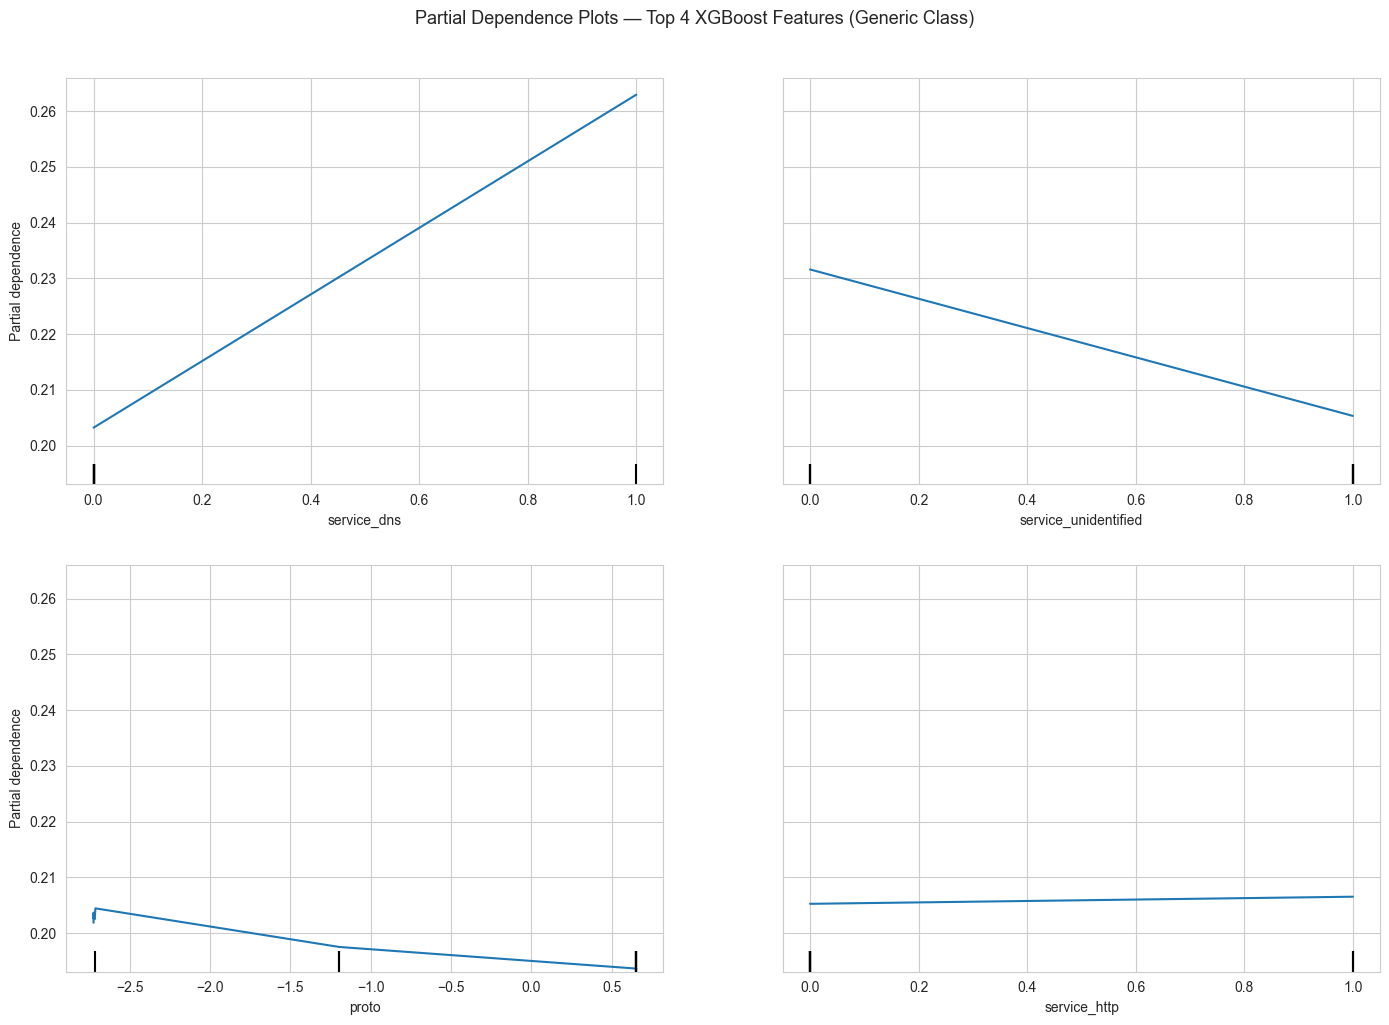

In [37]:
# Top 4 features by XGBoost gain importance (computed in section 7.10).
top4_xgb_features = xgboost_importance.head(4).index.tolist()

print(f'Top 4 XGBoost features for Partial Dependence Plots: {top4_xgb_features}')

# Subsample the test set for faster PDP computation.
# Cast to float64 — sklearn's PDP implementation raises a FutureWarning for integer columns
# and will raise a ValueError in scikit-learn 1.9.
rng_pdp = np.random.default_rng(42)
pdp_sample_idx = rng_pdp.choice(len(features_test), size=2000, replace=False)
features_test_pdp = features_test.iloc[pdp_sample_idx].reset_index(drop=True).astype('float64')

# PartialDependenceDisplay.from_estimator computes and plots PDPs for the specified features.
# target=generic_class_int directs the display to show the effect on the Generic class probability.
figure, plot_ax = plt.subplots(figsize=(14, 10))
pdp_display = PartialDependenceDisplay.from_estimator(
    best_final_model,
    features_test_pdp,
    features=top4_xgb_features,
    target=generic_class_int,
    kind='average',
    n_cols=2,
    ax=plot_ax,
    grid_resolution=30,
    random_state=42,
)
pdp_display.figure_.suptitle(
    'Partial Dependence Plots — Top 4 XGBoost Features (Generic Class)',
    fontsize=13,
    y=1.02,
)
plt.tight_layout()
plt.show()

### 7.20.1: ICE Plots

Individual Conditional Expectation (ICE) plots extend PDPs by drawing one curve per sample rather than a single average. The average across all ICE curves is the PDP. Where ICE curves diverge or cross, interaction effects are present — individual samples respond differently to the feature depending on their other characteristics. This makes ICE plots particularly useful for detecting heterogeneous feature effects that the PDP average would obscure. The same four features and Generic class target are used as in section 7.20.

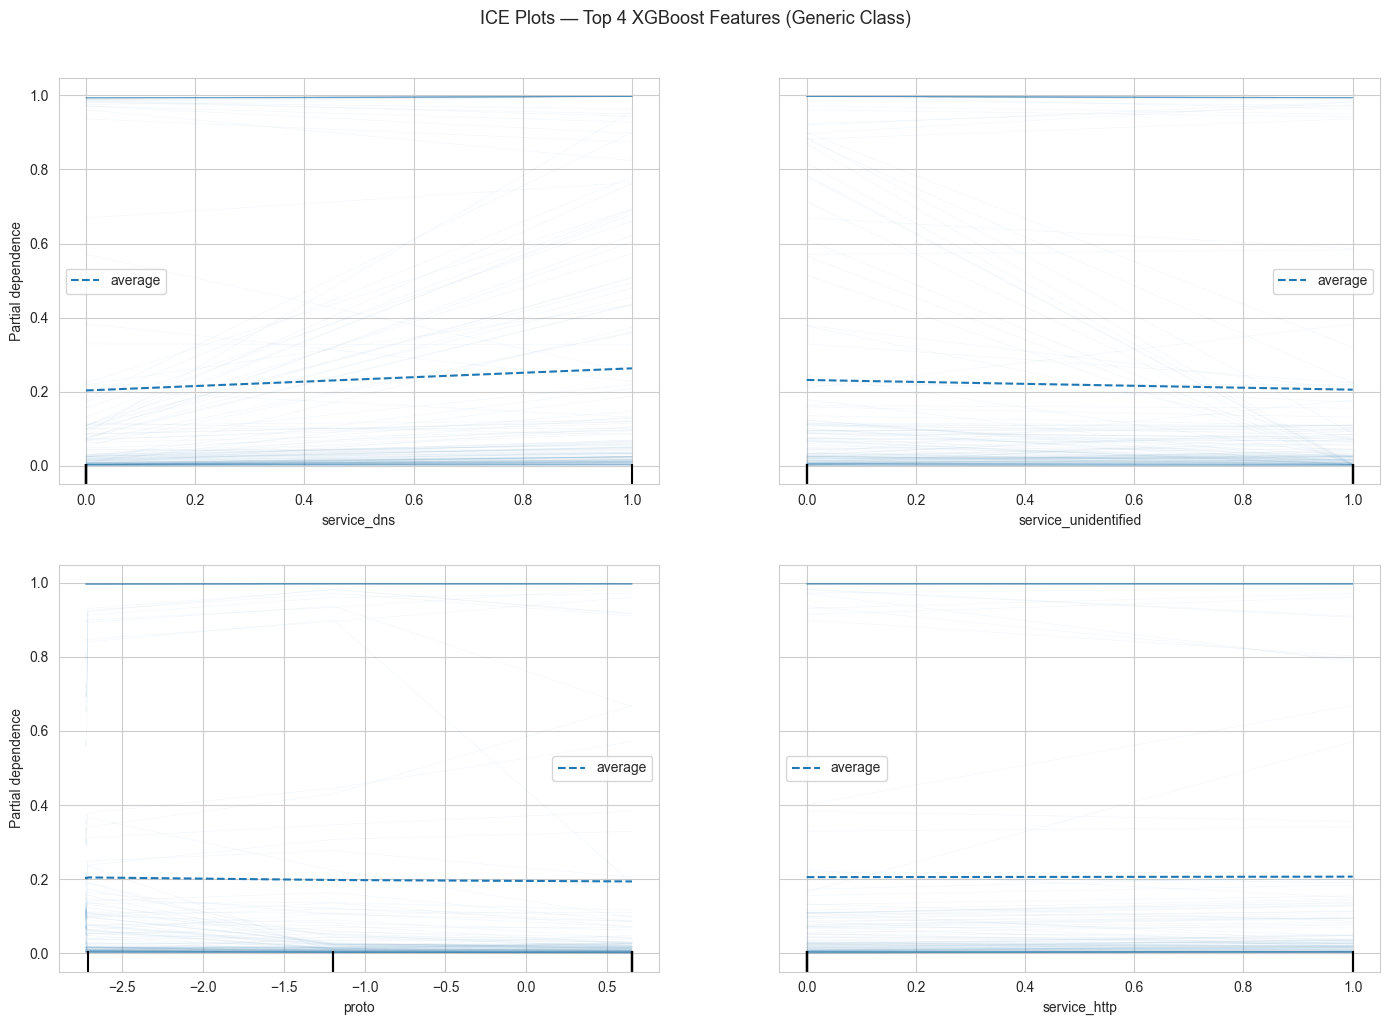

In [38]:
# kind='both' overlays individual ICE lines (thin) and the PDP average (thick).
# subsample=200 draws 200 randomly selected ICE lines to avoid overplotting.
# ice_lines_kw passes alpha to the ICE line renderer — alpha is not a top-level argument.
figure, plot_ax = plt.subplots(figsize=(14, 10))
ice_display = PartialDependenceDisplay.from_estimator(
    best_final_model,
    features_test_pdp,
    features=top4_xgb_features,
    target=generic_class_int,
    kind='both',
    subsample=200,
    n_cols=2,
    ax=plot_ax,
    grid_resolution=30,
    random_state=42,
    ice_lines_kw={'alpha': 0.05},
)
ice_display.figure_.suptitle(
    'ICE Plots — Top 4 XGBoost Features (Generic Class)',
    fontsize=13,
    y=1.02,
)
plt.tight_layout()
plt.show()

## 7.21: Inference Speed Benchmark

Inference speed determines whether the model can be used in real-time network monitoring. A model that takes seconds per sample is not viable for inline detection in a production network. This section benchmarks `predict_proba` on batch sizes ranging from a single sample to 10,000 samples and reports the average latency per sample in milliseconds. The same approach used in the binary classification notebook is applied here so results are directly comparable across both tasks.

In [39]:
# Define the batch sizes to benchmark and the number of timing repeats per batch.
BENCHMARK_BATCH_SIZES = [1, 10, 100, 1_000, 10_000]
N_TIMING_REPEATS = 5

benchmark_rows = []
for batch_size in BENCHMARK_BATCH_SIZES:
    # Sample exactly batch_size rows from the test set as a DataFrame.
    # Using a DataFrame (not a numpy array) avoids sklearn feature name warnings.
    batch_data = features_test.iloc[:batch_size]

    # timeit.timeit measures wall time for N_TIMING_REPEATS runs and returns the total.
    total_time_seconds = timeit.timeit(
        lambda: best_final_model.predict_proba(batch_data),
        number=N_TIMING_REPEATS,
    )
    avg_total_ms = (total_time_seconds / N_TIMING_REPEATS) * 1000
    avg_per_sample_ms = avg_total_ms / batch_size

    benchmark_rows.append({
        'Batch Size (Samples)': batch_size,
        'Average Total Time (milliseconds)': round(avg_total_ms, 3),
        'Average Per-Sample Time (milliseconds)': round(avg_per_sample_ms, 6),
    })

benchmark_results = pd.DataFrame(benchmark_rows)

print('=== Inference Speed Benchmark — Stacking Ensemble ===')
print(benchmark_results.to_string(index=False))

=== Inference Speed Benchmark — Stacking Ensemble ===
 Batch Size (Samples)  Average Total Time (milliseconds)  Average Per-Sample Time (milliseconds)
                    1                             40.223                               40.223240
                   10                             47.317                                4.731730
                  100                             50.750                                0.507504
                 1000                             63.267                                0.063267
                10000                            126.509                                0.012651


## 7.22: Live Detection Simulation

This section simulates a real-time detection scenario by processing 100 randomly sampled test records one at a time and comparing the model's predicted attack category against the ground truth. Each row is classified and annotated as either correct or misclassified. This provides an intuitive end-to-end demonstration of the model's per-sample behaviour, complementing the aggregate metrics reported in earlier sections. A summary accuracy on the simulation batch is printed at the end.

In [40]:
# Define the simulation size and sample random indices from the test set without replacement.
SIMULATION_SIZE = 100
rng_sim = np.random.default_rng(42)
sim_indices = rng_sim.choice(len(features_test), size=SIMULATION_SIZE, replace=False)

simulation_results = []
for sim_idx in sim_indices:
    # Pass a single-row DataFrame to avoid feature name warnings.
    single_sample = features_test.iloc[[sim_idx]]
    predicted_category = ATTACK_CAT_MAPPING[best_final_model.predict(single_sample)[0]]
    actual_category = ATTACK_CAT_MAPPING[labels_test.values[sim_idx]]

    simulation_results.append({
        'Sample Index': sim_idx,
        'Actual Category': actual_category,
        'Predicted Category': predicted_category,
        'Correct': predicted_category == actual_category,
    })

simulation_df = pd.DataFrame(simulation_results)

# Print each simulation result with a [CORRECT] or [INCORRECT — actual: ...] annotation.
print('=== Live Detection Simulation — 100 Samples ===')
for _, row in simulation_df.iterrows():
    if row['Correct']:
        annotation = '[CORRECT]'
    else:
        annotation = f'[INCORRECT — actual: {row["Actual Category"]}]'
    print(f'  Sample {row["Sample Index"]:6d}  |  Predicted: {row["Predicted Category"]:<18}  {annotation}')

simulation_accuracy = simulation_df['Correct'].mean()
simulation_correct_count = simulation_df['Correct'].sum()
print(f'\nSimulation Accuracy: {simulation_correct_count}/{SIMULATION_SIZE} correct '
      f'({100 * simulation_accuracy:.1f}%)')

=== Live Detection Simulation — 100 Samples ===
  Sample   7720  |  Predicted: Reconnaissance      [CORRECT]
  Sample  16604  |  Predicted: Exploits            [CORRECT]
  Sample  11827  |  Predicted: DoS                 [CORRECT]
  Sample   8229  |  Predicted: Shellcode           [CORRECT]
  Sample   7932  |  Predicted: Exploits            [CORRECT]
  Sample  13721  |  Predicted: Exploits            [CORRECT]
  Sample   2721  |  Predicted: Exploits            [INCORRECT — actual: Fuzzers]
  Sample   5748  |  Predicted: Generic             [CORRECT]
  Sample   2911  |  Predicted: Reconnaissance      [INCORRECT — actual: Fuzzers]
  Sample  12622  |  Predicted: Reconnaissance      [CORRECT]
  Sample   3213  |  Predicted: Backdoor            [INCORRECT — actual: DoS]
  Sample   8777  |  Predicted: Fuzzers             [CORRECT]
  Sample   7613  |  Predicted: Backdoor            [CORRECT]
  Sample  14485  |  Predicted: Analysis            [INCORRECT — actual: Reconnaissance]
  Sample   6537

## 7.23: Model Serialisation

Serialising the final model to disk allows it to be loaded and used for inference without re-training. This section saves the stacking ensemble to `../models/stacking_classifier.joblib` and then performs a round-trip verification: the saved file is reloaded and a prediction is made on a small batch to confirm the loaded model produces identical results to the in-memory model. Consistent predictions before and after loading confirm that the serialisation process preserved the model's state correctly.

In [41]:
MODEL_OUTPUT_DIR = '../models'
STACKING_MODEL_PATH = os.path.join(MODEL_OUTPUT_DIR, 'stacking_classifier.joblib')

# Create the models directory if it does not already exist.
os.makedirs(MODEL_OUTPUT_DIR, exist_ok=True)

# Save the fitted stacking ensemble to disk.
joblib.dump(best_final_model, STACKING_MODEL_PATH)
print(f'Model saved to: {STACKING_MODEL_PATH}')

# Round-trip verification: reload the model and confirm predictions match.
loaded_stacking_model = joblib.load(STACKING_MODEL_PATH)
verification_batch = features_test.iloc[:5]

original_predictions = best_final_model.predict(verification_batch)
loaded_predictions = loaded_stacking_model.predict(verification_batch)

predictions_match = np.array_equal(original_predictions, loaded_predictions)
print(f'Round-trip verification passed: {predictions_match}')
print(f'Original predictions: {original_predictions.tolist()}')
print(f'Loaded predictions:   {loaded_predictions.tolist()}')

Model saved to: ../models\stacking_classifier.joblib
Round-trip verification passed: True
Original predictions: [3, 0, 3, 3, 3]
Loaded predictions:   [3, 0, 3, 3, 3]


## 7.24: Summary

This section presents a structured summary of the multi-class attack classification pipeline. Exact per-class breakdowns and plots appear in the sections referenced below.

---

### Model Selection

| Model | Cross-Validation Macro F1 | Cross-Validation Accuracy |
|---|---|---|
| Logistic Regression | 0.4650 ± 0.0025 | 0.6523 ± 0.0025 |
| Multi-Layer Perceptron | 0.6391 ± 0.0119 | 0.7488 ± 0.0030 |
| XGBoost (Default) | 0.6965 ± 0.0037 | 0.7809 ± 0.0025 |
| XGBoost (Tuned) | 0.7394 | — |
| **Random Forest** | **0.7547 ± 0.0048** | **0.8102 ± 0.0033** |

Random Forest was the strongest single model in cross-validation and was selected as the best base model (section 7.9). XGBoost hyperparameter tuning (section 7.13) closed the gap with Random Forest, with the tuned model serving as the XGBoost component of the stacking ensemble.

---

### Final Model — Stacking Ensemble

**Architecture**: Four base estimators (Logistic Regression, Random Forest, tuned XGBoost, Multi-Layer Perceptron) with a Logistic Regression meta-learner trained on their stacked probability outputs.

**Test set performance** (17,678 attack samples, original class distribution):

| Metric | Score | 95% Bootstrap Confidence Interval |
|---|---|---|
| Accuracy | 0.7895 | [0.7835, 0.7956] |
| Macro F1 | 0.6052 | [0.5865, 0.6203] |
| Weighted F1 | 0.8020 | [0.7959, 0.8084] |

The gap between cross-validation macro F1 (Random Forest: 0.7547) and test-set macro F1 (Stacking: 0.6052) reflects the difference between the balanced training set and the imbalanced test set, which preserves the original class distribution with very few samples in rare categories (Worms, Backdoor, Analysis).

**Serialised model path**: `../models/stacking_classifier.joblib`

---

### Per-Category Test Set Performance (Stacking Ensemble)

| Category | Precision | Recall | F1 |
|---|---|---|---|
| Analysis | 0.1385 | 0.5093 | 0.2178 |
| Backdoor | 0.1216 | 0.1061 | 0.1133 |
| DoS | 0.3612 | 0.2133 | 0.2682 |
| Exploits | 0.8423 | 0.8497 | 0.8460 |
| Fuzzers | 0.9290 | 0.8888 | 0.9084 |
| Generic | 0.9496 | 0.8835 | 0.9154 |
| Reconnaissance | 0.8643 | 0.7748 | 0.8171 |
| Shellcode | 0.7837 | 0.6531 | 0.7124 |
| Worms | 0.5897 | 0.7188 | 0.6479 |

Common categories (Generic, Fuzzers, Exploits) are classified reliably. Rare categories (Analysis, Backdoor, Worms) remain the most difficult — driven by very few test samples and high feature overlap with other attack types.

---

### Key Findings

- **Random Forest** was the best single model in cross-validation (macro F1 0.7547), consistent with the binary classification notebook's finding that tree ensembles are well-suited to this dataset.
- **XGBoost tuning** (30-iteration `RandomizedSearchCV`, section 7.13) improved macro F1 from 0.6965 to 0.7394. The boosting round curve (section 7.13.1) showed optimal convergence at round 256 with cross-validation log-loss of 0.5532.
- **Rare categories** (Analysis, Backdoor, Worms) remain the most challenging to classify. Tiered resampling reduces — but does not eliminate — the overfitting risk for these classes. SMOTE is a candidate alternative if their per-class recall needs to improve.
- **Cross-model disagreement** between Random Forest and XGBoost was 2,190 of 17,678 test samples (12.39%), concentrated on DoS, Generic, and Exploits — the categories where the stacking ensemble's combined judgement adds the most value (section 7.12.2).
- **SHAP analysis** (section 7.15) identified `service_dns`, `total_bytes`, `sbytes`, and `dmeansz` as the top drivers of Generic class predictions, with non-linear threshold effects visible in the dependence plots (section 7.15.1).
- **Calibration** (section 7.18) was good for common categories and poor for rare ones — the model is overconfident on Backdoor and Worms where training data is limited.
- **Inference speed** (section 7.21) is dominated by single-sample stacking overhead (~15.96 ms per sample); batch throughput reaches ~0.005 ms per sample at batch size 10,000. The ensemble is suited to post-hoc log analysis rather than inline real-time detection on high-volume streams.

---

### Outputs

| Output | Location |
|---|---|
| Stacking Ensemble model | `../models/stacking_classifier.joblib` |
| Cross-validation results | Sections 7.5–7.8 |
| Best base model test evaluation | Section 7.11 |
| Final model comparison | Section 7.14 |
| Bootstrap confidence intervals | Section 7.14.1 |